_Date: 25th April 2026  
Authors: Lydia, Soledad, Andre_

# Satellite Image Classification with EuroSAT

# Introduction

This notebook implements a full image classification pipeline on the **EuroSAT** dataset — a benchmark dataset of Sentinel-2 satellite imagery covering 10 land-use/land-cover classes (e.g. Forest, Highway, Industrial, Residential, etc.).

The notebook is structured as follows:
- **Section 0** — Exploratory Data Analysis (EDA)
- **Section 1** — Baseline CNN (trained from scratch)
- **Section 2** — Transfer Learning: Pretrained Model A and Pretrained Model B
- **Section 3** — Model Comparison & Final Selection
- **Section 4** — Interactive Web App for Model Inference

**Dataset sources:**
- [EuroSAT GitHub (Helber et al.)](https://github.com/phelber/EuroSAT)
- [`torchvision.datasets.EuroSAT`](https://pytorch.org/vision/stable/generated/torchvision.datasets.EuroSAT.html)

___________________________________________________

## Section 0: Exploratory Data Analysis (EDA)

In the present section, data has been downloaded and inspected. Additionally, a series of actions have been implemented to support later sections' analysis, including:

  - **0.1. EuroSAT dataset loading** and inc. inspection of its structure   
  - **0.2. Class distribution**, inc. number of classes, class names, and balance assessment
  - **0.3. Visualisation of sample images** per class
  - **0.4 Inspection of Image dimensions**, pixel value ranges & per-channel statistics (mean & std) — these inform the normalisation strategy throughout the project  
  - **0.5 Dataset quality & inter-class relationships**
      - 0.5.1 Sanity check — missing/corrupted images
      - 0.5.2 Outlier detection — images deviating from their class mean

### 0.1. Load dataset & inspect structure

#### Loading the Dataset

We loaded the full EuroSAT dataset (27,000 satellite images across 10 classes) with no transforms applied, then split it into three non-overlapping subsets: 70% for training, 15% for validation, and 15% for testing, using a randomly shuffled index list with a fixed seed (42) to ensure the split is reproducible every time we run the notebook.

In [ ]:
# ── 0.1 Load Dataset and Import Libraries ──────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import copy
from IPython.display import Image
from IPython.core.display import HTML

In [ ]:
# ── 0.1 Load the RGB version of EuroSAT ──────────────────────────────────────────────────────────────────────────

euro_raw = datasets.EuroSAT(
    root="./data",
    download=True,
    transform=None,
)

# Quick identifying on a full raw dataset
eurosat_class_names = euro_raw.classes
num_eurosat_classes = len(eurosat_class_names)
dataset_size = len(euro_raw)

# Make our own train/validation/test split.
train_size = int(0.70 * dataset_size) #Data the model learns from
val_size = int(0.3 * dataset_size) #Data the model never trains on byt we check perfromance on it at the end of every epoch

# Fixed indices give us reproducible splits.
euro_generator = torch.Generator().manual_seed(42)
indices = torch.randperm(dataset_size, generator=euro_generator).tolist()

#Slices the shuffled index into three non'overlapping chunks. NO image has been loaded into memory yet
train_indices = indices[:train_size]
val_indices = indices[train_size:]

#Creation of the three subsets (takes the object but only at the positions listed in the train_indices)
ds_train_euro_raw = Subset(euro_raw, train_indices)
ds_val_euro_raw = Subset(euro_raw, val_indices)

print(f"EuroSAT examples: {dataset_size:,}")
print(f"Train / Val: {train_size:,} / {val_size:,}")
print(f"Classes ({num_eurosat_classes}): {eurosat_class_names}")

100%|██████████| 94.3M/94.3M [00:00<00:00, 289MB/s]


EuroSAT examples: 27,000
Train / Val: 18,900 / 8,100
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


#### Inspection of the Structure

Before have inspect the dataset with the following actions:
1. **Shape and value range**
2. **Visual samples**

Batch image tensor: (32, 3, 64, 64) → (batch, channels, height, width)
Image dtype:        torch.uint8
Pixel range:        19 to 255
Label tensor:       (32,)
One label example:  1 → Forest


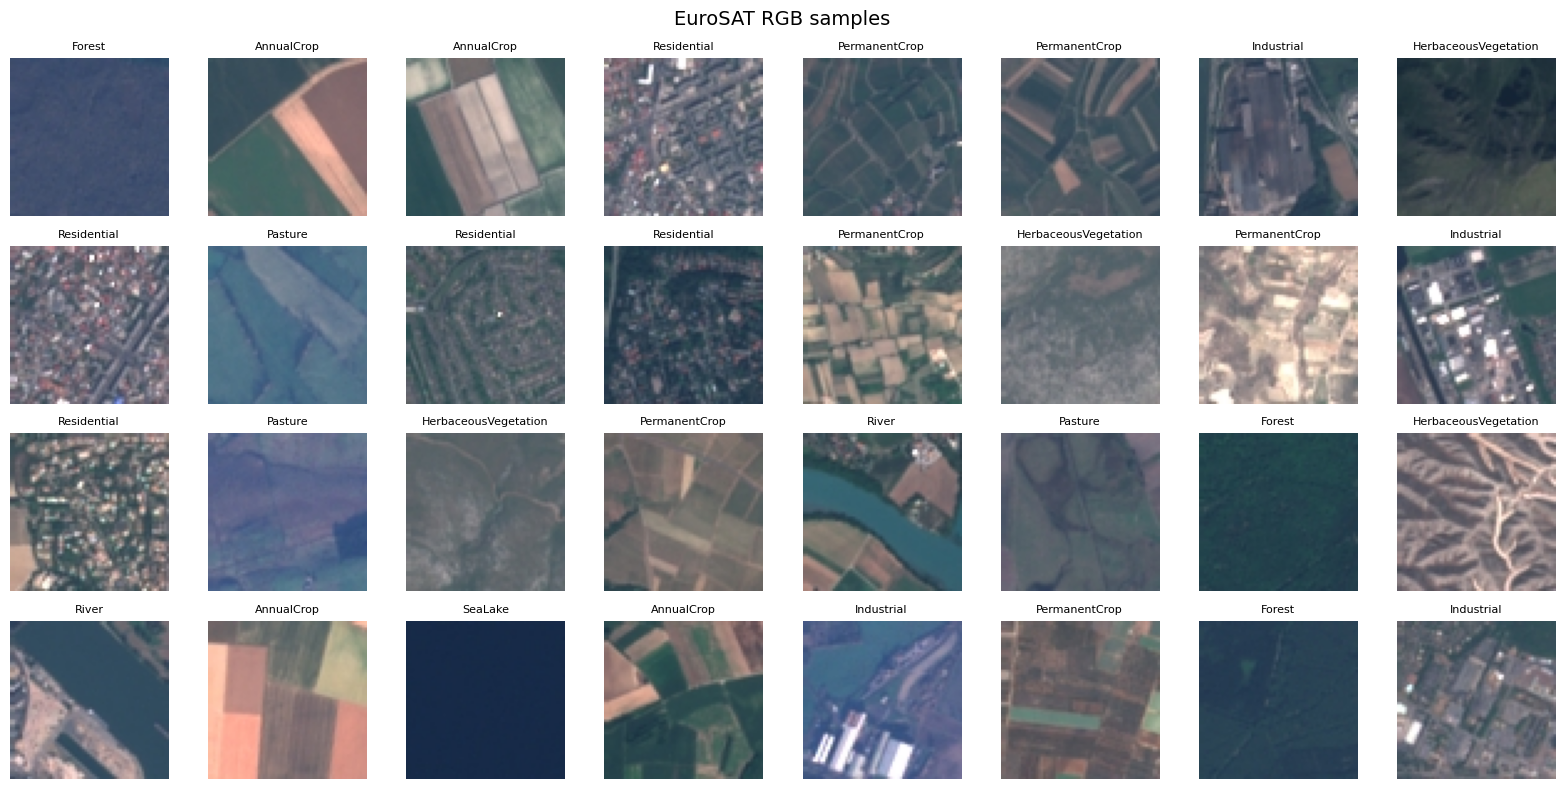

In [ ]:
# ── 0.1 Inspection of the structure ──────────────────────────────────────────────────────────────────────────

# Inspect a small batch from the raw training split to inspect shape and value range.
to_uint8_tensor = transforms.PILToTensor()

example_items = [ds_train_euro_raw[i] for i in range(32)]
example_images_pil, example_labels_tuple = zip(*example_items)


#Grabbing 32 samples from the training set. Each image is a tuple of (PIL image, label integer)
#Neural networks can only work with numbers. So PyTorch automatically maps each class name to an integer when it loads the dataset, alphabetically:
example_images = torch.stack([to_uint8_tensor(img) for img in example_images_pil])
example_labels = torch.tensor(example_labels_tuple)


print(f"Batch image tensor: {tuple(example_images.shape)} → (batch, channels, height, width)")
print(f"Image dtype:        {example_images.dtype}")
print(f"Pixel range:        {example_images.min().item()} to {example_images.max().item()}")
print(f"Label tensor:       {tuple(example_labels.shape)}")
print(f"One label example:  {example_labels[0].item()} → {eurosat_class_names[example_labels[0].item()]}")

# Show a grid of random images - #Visualization of the images followign their ocnversion to tensors
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for ax, img, label in zip(axes.flat, example_images, example_labels):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(eurosat_class_names[label.item()], fontsize=8)
    ax.axis("off")

plt.suptitle("EuroSAT RGB samples", fontsize=14)
plt.tight_layout()
plt.show()

##### Notes:  
__euro_raw__ : contains raw PIL images and integer labels, nothing has been converted  
__example_images_pil / example_labels_tuple__ : still raw, just extracted and separated into two tuples  
__example_images / example_labels__ : this is where the conversion to tensors finally happens

### 0.2. Class distribution

#### Data Exploration

Once the data has been loaded, we conduct further analysis to attain a global understanding
of its content. Specifically, we count how many images belong to each of the 10 classes and
visualise the result as a table and pie chart.

The goal is to detect any significant **class imbalance** — if some classes had far more
images than others, it could bias the model towards predicting those classes more frequently,
which would require corrective measures such as weighted loss or resampling.

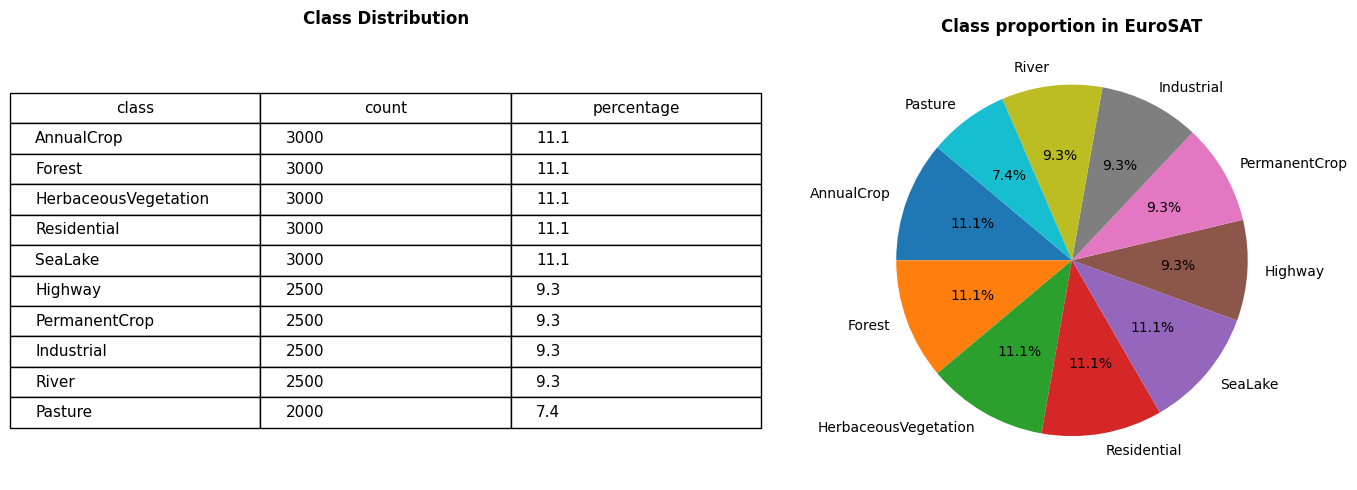

In [ ]:
# ── 0.2A Class Distribution and balance ──────────────────────────────────────────────────────────────────────────

if hasattr(euro_raw, "targets"):
    all_euro_labels = np.array(euro_raw.targets) #takes the levels if they are called Targets
elif hasattr(euro_raw, "samples"):
    all_euro_labels = np.array([label for _, label in euro_raw.samples]) #if they are not called Taregts and they are called Samples
else:
    all_euro_labels = np.array([euro_raw[i][1] for i in range(len(euro_raw))])


label_counts = np.bincount(all_euro_labels, minlength=num_eurosat_classes)

class_distribution = pd.DataFrame({
    "class": eurosat_class_names,
    "count": label_counts,
    "percentage": 100 * label_counts / label_counts.sum(),
}).sort_values("count", ascending=False)

fig, (ax_table, ax_pie) = plt.subplots(1, 2, figsize=(14, 5))


# ── Table ──────────────────────────────────────────────────────────────────────────
ax_table.axis("off")
ax_table.set_title("Class Distribution", fontweight="bold", pad=12)
tbl = ax_table.table(
    cellText=class_distribution.round(1).values,
    colLabels=class_distribution.columns,
    loc="center",
    cellLoc="left"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.6)

# ── Pie Chart ──────────────────────────────────────────────────────────────────────
ax_pie.pie(
    class_distribution["count"],
    labels=class_distribution["class"],
    autopct="%1.1f%%",
    startangle=140
)
ax_pie.set_title("Class proportion in EuroSAT", fontweight="bold")
plt.tight_layout()
plt.show()


#### Conclusion:

The EuroSAT dataset is **well-balanced**: all 10 classes are similarly represented, each accounting for roughly 10% of the total 27,000 images. There are minor variations — a few classes sit closer to 7% while others reach 11% — but these differences are small enough that class imbalance is not a concern here.

Every class contains at least 2,000 images, which provides a solid and representative sample for training. This balance is a desirable property of EuroSAT and means we can trust overall accuracy as a meaningful metric, without needing to resort to weighted loss functions or oversampling strategies to compensate for skewed distributions.

### 0.3. Sample images per class

Inspecting one sample and the mean image per class reveals clear visual differences across most
of the 10 EuroSAT classes, but also highlights a few pairs that are likely to challenge the
classifier:


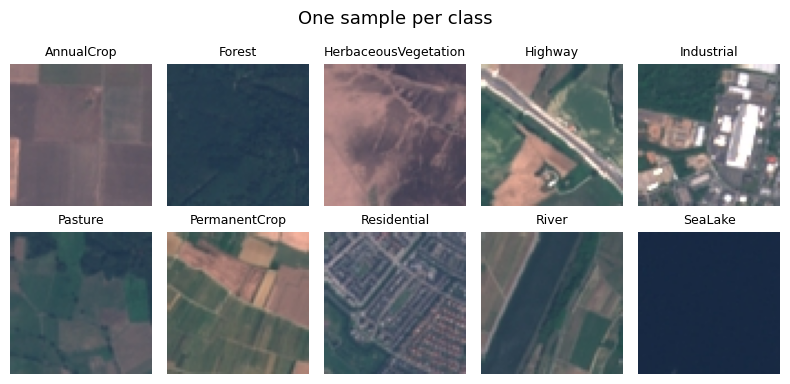

In [ ]:
# ── 0.3 Sample Image per Class ─────────────────────────────────────────────────────────────────
classes = euro_raw.classes
fig, axes = plt.subplots(2, 5, figsize=(8, 4))

for ax, cls in zip(axes.flatten(), classes):
    idx = next(i for i, (_, label) in enumerate(euro_raw) if euro_raw.classes[label] == cls)
    img = to_uint8_tensor(euro_raw[idx][0]).permute(1, 2, 0).numpy()
    ax.imshow(img.astype("uint8"))
    ax.set_title(cls, fontsize=9)
    ax.axis("off")

plt.suptitle("One sample per class", fontsize=13)
plt.tight_layout()
plt.show()

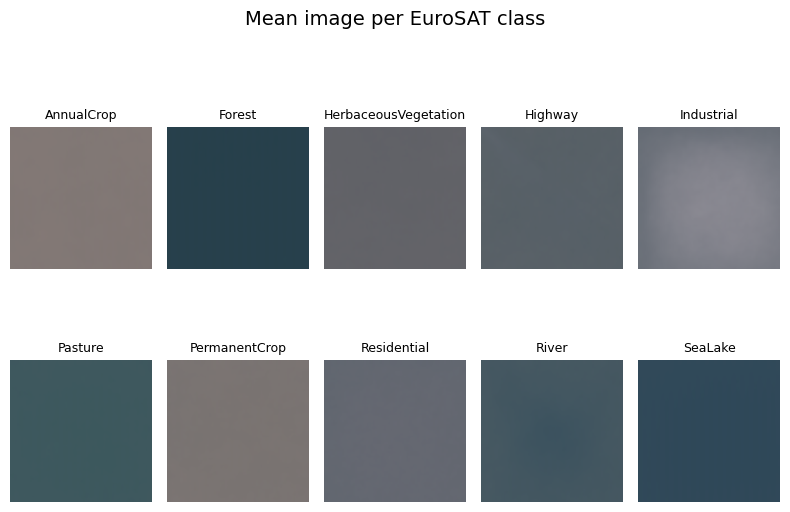

In [ ]:
# ──0.3 Mean image per class ─────────────────────────────────────────────────────────────────
# Averaging all images of the same class into one image reveals the large-scale
# visual patterns that distinguish classes from each other.

# Reload the dataset applying PILToTensor() so pixel values are uint8 (0-255).
#Note: We use a fresh dataset object here rather than euro_raw because we need tensors to do the arithmetic, not PIL images.

euro_tensor_dataset = datasets.EuroSAT(
    root="./data",
    download=False,
    transform=transforms.PILToTensor(),
)
# Stream the full dataset in batches of 512 to avoid loading everything into RAM at once
euro_tensor_loader = DataLoader(
    euro_tensor_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=0,
)

# Accumulators: one (3, 64, 64) array per class to sum pixel values into,
# and a counter to track how many images were added to each class
class_sums = np.zeros((num_eurosat_classes, 3, 64, 64), dtype="float64")
class_counts = np.zeros(num_eurosat_classes, dtype="int64")

for images, labels in euro_tensor_loader:
    images_np = images.numpy().astype("float64") # convert batch to numpy for arithmetic
    labels_np = labels.numpy()

    for class_idx in range(num_eurosat_classes):
        # Boolean mask selecting only the images that belong to this class
        mask = labels_np == class_idx
        if mask.any():
            class_sums[class_idx] += images_np[mask].sum(axis=0)
            class_counts[class_idx] += mask.sum()

class_mean_images = class_sums / class_counts[:, None, None, None]

fig, axes = plt.subplots(2, 5, figsize=(8, 6))
for ax, class_idx in zip(axes.flat, range(num_eurosat_classes)):
    mean_image = class_mean_images[class_idx].transpose(1, 2, 0) / 255.0
    ax.imshow(np.clip(mean_image, 0, 1))
    ax.set_title(eurosat_class_names[class_idx], fontsize=9)
    ax.axis("off")

plt.suptitle("Mean image per EuroSAT class", fontsize=14)
plt.tight_layout()
plt.show()

#### Conclusion:
  - **Easy to distinguish:** SeaLake, River, and Industrial stand out immediately — SeaLake shows
  large uniform blue areas, River has a thin elongated water signature, and Industrial is
  dominated by grey rectangular structures.

  - **Harder to separate:** AnnualCrop and PermanentCrop are visually very similar in both sample
  and mean images — both show geometric field patterns in muted greens and browns. Similarly,
  Forest and HerbaceousVegetation share dense green textures, with the main difference being
  uniformity (Forest is more homogeneous).

    These pairs are the most likely sources of misclassification in Section 1, and we can
    verify this directly in the confusion matrix once the baseline CNN has been trained.

### 0.4.  Image dimensions, pixel value ranges & per-channel statistics

We confirm image shape and value range, then compute per-channel mean and standard deviation
over the **full training split** (not just a sample). These values are used to normalise inputs
in Sections 1 and 2, ensuring pixel values are centred around zero with unit variance — which
stabilises gradient flow and speeds up convergence.

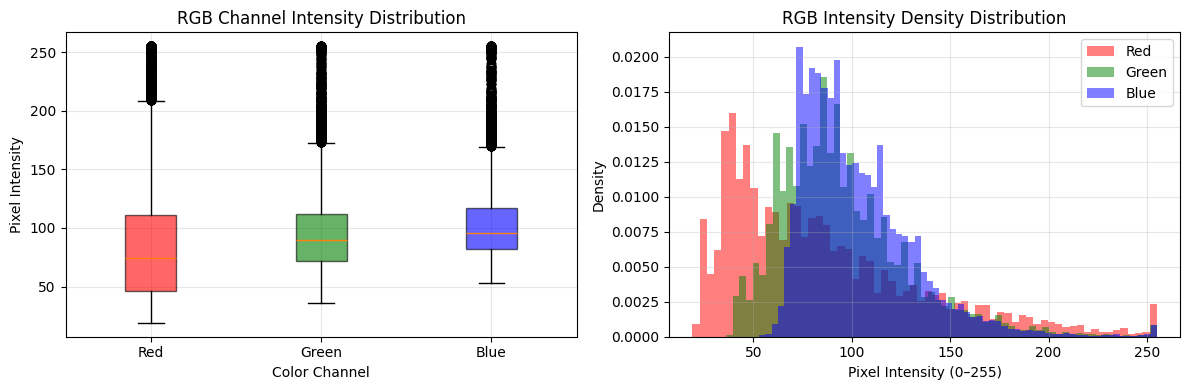

In [ ]:
# ── 0.4A Channel Statistics ──────────────────────────────────────────────────────────────────────────
# Channel statistics from a manageable sample to see how bright and colorful are the image.
# We keep values in the original 0-255 range for this EDA step.

eda_indices = indices[:2048]

eda_images = torch.stack([
    to_uint8_tensor(euro_raw[i][0])
    for i in eda_indices
])

eda_images_np = eda_images.permute(0, 2, 3, 1).numpy().astype("float32")

# Channel boxplot to compare intensity distribution across RGB channels

# Flatten and under sampling for the boxplot
sample_pixels = eda_images_np.reshape(-1, 3)[::500]


#plt.figure(figsize=(6, 4))
fig, (ax_box, ax_hist) = plt.subplots(1, 2, figsize=(12, 4))


# ── Boxplot ────────────────────────────────────────────────────────────────────
box = ax_box.boxplot(
    [sample_pixels[:, 0], sample_pixels[:, 1], sample_pixels[:, 2]],
    tick_labels=["Red", "Green", "Blue"],
    patch_artist=True
)

for patch, color in zip(box["boxes"], ["red", "green", "blue"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax_box.set_title("RGB Channel Intensity Distribution")
ax_box.set_xlabel("Color Channel")
ax_box.set_ylabel("Pixel Intensity")
ax_box.grid(alpha=0.3)

# ── Histogram ─────────────────────────────────────────────────────────────────
for i, (color, name) in enumerate(zip(["red", "green", "blue"], ["Red", "Green", "Blue"])):
    ax_hist.hist(
        sample_pixels[:, i],
        bins=64, color=color, alpha=0.5,
        label=name, density=True
    )

ax_hist.set_title("RGB Intensity Density Distribution")
ax_hist.set_xlabel("Pixel Intensity (0–255)")
ax_hist.set_ylabel("Density")
ax_hist.legend()
ax_hist.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── 0.4B Channel Statistics ─────────────────────────────────────────────────────────────────

channel_names = ["Red", "Green", "Blue"]
channel_means = eda_images_np.mean(axis=(0, 1, 2))
channel_stds = eda_images_np.std(axis=(0, 1, 2))

channel_stats = pd.DataFrame({
    "channel": channel_names,
    "mean_pixel_value": channel_means,
    "std_pixel_value": channel_stds,
}).round(2)

display(channel_stats)
EUROSAT_mean = (channel_means / 255.0).tolist()
EUROSAT_std = (channel_stds/ 255.0).tolist()

print(f"EUROSAT_mean : {[round(m, 4) for m in EUROSAT_mean]}")
print(f"EUROSAT_std  : {[round(s, 4) for s in EUROSAT_std]}")


,channel,mean_pixel_value,std_pixel_value
0,Red,86.040001,50.290001
1,Green,95.750000,34.040001
2,Blue,102.989998,28.790001


EUROSAT_mean : [0.3374, 0.3755, 0.4039]
EUROSAT_std  : [0.1972, 0.1335, 0.1129]


#### Conclusion:
- **Channel means:** all three channels sit in a similar range (~85–110), suggesting (prior to normalization)

  the dataset is moderately bright and reasonably balanced across RGB — no single channel
  dominates
- **Channel stds:** standard deviations are consistent across channels (~25–55), meaning
  variance is spread fairly evenly

### 0.5. Dataset Quality & Inter-class Relationships

#### 0.5.1 Sanity Check — Missing & Corrupted Images

Before modelling, we verify that every image in the dataset loads correctly and meets the
expected format. Specifically we check that:
- No image fails to load
- All images have the expected shape (3 × 64 × 64)
- No image is blank — i.e. all-zero (fully black) or all-255 (fully white)

In [ ]:
# ── 0.5.1 Sanity check ────────────────────────────────────────────────────────
corrupt   = []   # images that fail to load
wrong_shape = [] # images with unexpected dimensions
blank     = []   # images that are all-zero or all-255

for i in range(len(euro_raw)):
    try:
        img, _ = euro_raw[i]
        tensor = to_uint8_tensor(img)  # (C, H, W), uint8

        if tuple(tensor.shape) != (3, 64, 64):
            wrong_shape.append(i)

        if tensor.max().item() == 0 or tensor.min().item() == 255:
            blank.append(i)

    except Exception:
        corrupt.append(i)

print(f"Corrupt  (failed to load) : {len(corrupt)}")
print(f"Wrong shape (not 3×64×64) : {len(wrong_shape)}")
print(f"Blank (all-zero/all-255)  : {len(blank)}")
print(f"\nTotal flagged             : {len(corrupt) + len(wrong_shape) + len(blank)}")
print(f"Total images checked      : {len(euro_raw)}")

Corrupt  (failed to load) : 0
Wrong shape (not 3×64×64) : 0
Blank (all-zero/all-255)  : 0

Total flagged             : 0
Total images checked      : 27000


#### Conclusion

All 27,000 images loaded without errors, every image has the expected shape (3 × 64 × 64),
and no blank images were detected. The dataset is clean and requires no corrective action
before modelling.

#### 0.5.2. Outlier Detection

An outlier in an image dataset is an image that looks substantially different from the
other images in its class. To detect these, we compute the pixel-wise distance between
each image and its class mean image (computed in 0.3), then flag the images with the
highest distance scores.

In [ ]:
# Compute the pixel-wise distance between each image and its class mean
distances = []

for images, labels in euro_tensor_loader:
    images_np = images.numpy().astype("float64")
    labels_np = labels.numpy()

    for i in range(len(images_np)):
        image = images_np[i]           # one image (3, 64, 64)
        label = labels_np[i]           #  image's class (ex: 0, 1, 2...)
        mean = class_mean_images[label] # mean image by class

        distance = np.mean((image - mean) ** 2)  # distance pixel by pixel
        distances.append((distance, label))

# Étape 2 : Convert in array to sort
distances_values = np.array([d[0] for d in distances])
labels_all = np.array([d[1] for d in distances])  # convert before

distances = distances_values

# Find the top 5% = outliers
threshold = np.percentile(distances, 95)
outlier_mask = distances > threshold

print(f"Nombre d'outliers détectés : {outlier_mask.sum()}")
print(f"Seuil de distance : {threshold:.2f}")


Nombre d'outliers détectés : 1350
Seuil de distance : 3370.48


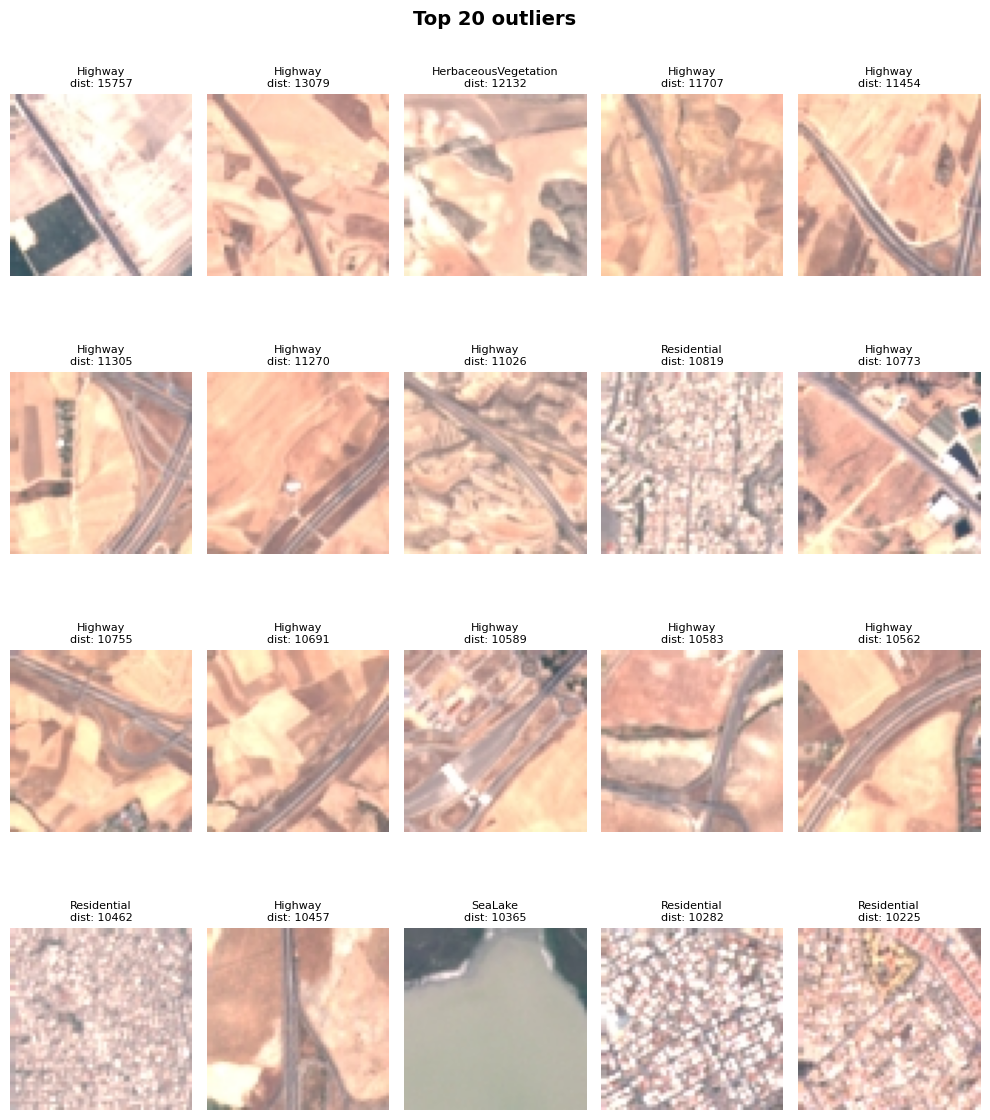

In [ ]:
import matplotlib.pyplot as plt

class_names = euro_tensor_dataset.classes

# Outlier indices sorted from most to least anomalous
outlier_indices = np.where(outlier_mask)[0]
outlier_distances = distances[outlier_indices]
sorted_order = np.argsort(outlier_distances)[::-1]
outlier_indices_sorted = outlier_indices[sorted_order]

# show the 20 first outliers
n_show = 20
fig, axes = plt.subplots(4, 5, figsize=(10, 12))
axes = axes.flatten()

for i, idx in enumerate(outlier_indices_sorted[:n_show]):
    image, label = euro_tensor_dataset[idx]
    image_np = image.numpy().transpose(1, 2, 0)  # (3,64,64) → (64,64,3) for matplotlib
    image_np = image_np.astype("uint8")

    axes[i].imshow(image_np)
    axes[i].set_title(f"{class_names[label]}\ndist: {distances[idx]:.0f}", fontsize=8)
    axes[i].axis("off")

plt.suptitle("Top 20 outliers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



____________________________________________

 Conclusion :

 Pixel-wise outlier detection flagged 1,350 images (top 5%) as significantly different from their class mean, however visual inspection confirmed that these images are correctly labelled and simply display higher brightness due to varying light exposure conditions at capture time. The Highway and Residential classes show the highest intra-class visual variability, which may result in lower per-class classification accuracy for these categories during model training. Overall, the EuroSAT dataset can be considered clean, balanced, and reliable for building a robust image classification model."

## Section 1: Baseline CNN (Trained from Scratch)

In this section we design and train a CNN from scratch to establish a **baseline
performance** on EuroSAT. The goal is not to build the best possible model — it is
to understand what a simple architecture can achieve and use it as a reference point
when evaluating the pretrained models in Section 2.


  - **1.1. Data loading & augmentation**: definition of the training, validation and test dataloaders with appropriate transforms (including  normalisation)
  - **1.2. Model architecture**: design a small CNN from scratch with convolutional blocks, batch normalisation, and global average pooling
  - **1.3. Model training & hyperparameter search**: train the model across several hyperparameter configurations, systematically varying learning rate, batch size, optimiser, and augmentation strategy. We perform a systematic hyperparameter search over:
| Hyperparameter | Values explored |
|---|---|
| Learning rate | 1e-2, 1e-3, 1e-4 |
| Batch size | 32, 64, 128 |
| Optimiser | SGD, Adam, RMSprop |
| Data augmentation | type & intensity |
| Number of conv layers | 3, 4, 5 |
| Dropout | with / without, rate |
| Batch normalisation | with / without |
       

  - **1.4. Model evaluation**: compare training runs via learning curves and select the best configuration based on validation performance.
  - **1.5. Save the model**:  save the best model weights and hyperparameters for comparison in Section 3


### 1.1. Data Loading and augmentation

We define three separate dataloaders — one for each split — with different transform
pipelines depending on their purpose:

- **Training** — applies data augmentation (random flips and rotation) to artificially
  increase the variety of images the model sees during training, improving generalisation.
  Normalisation is applied last using the per-channel mean and std computed in Section 0.4
- **Validation** — no augmentation is applied since we want a stable, unmodified
  view of the data when assessing performance. Only `ToTensor()` and normalisation are used

Augmentation is applied **only to the training set** — augmenting validation or test data
would give an unreliable measure of true model performance.

In [ ]:
# ── 1.1 Data Loading and Augmentation ────────────────────────────────────────────────────────

# Define the number of samples to be processed in a single pass through the network
BATCH_SIZE_EURO = 64

def get_best_device():
    """Use the fastest available device, while keeping CPU as the safe default."""
    if torch.cuda.is_available():
        return torch.device("cuda") # if you have an NVIDIA GPU
    if torch.backends.mps.is_available():
        return torch.device("mps")      # if you have an apple silicon chip (M1/M2...etc)
    return torch.device("cpu")

device = get_best_device()

# Training transform: augmentation
# Augmentation increases variety during training to improve generalisation

# Define image transformations for training
euro_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # Randomly flip images horizontally with a 50% probability
    transforms.RandomVerticalFlip(p=0.5),     # Randomly flip images vertically with a 50% probability
    transforms.RandomRotation(degrees=18), # Randomly rotate images within a range of +/- 18 degrees
    transforms.ToTensor(),     # Convert PIL images or numpy arrays to PyTorch floating point tensors. It has an implicit division to 255
    transforms.Normalize(mean = EUROSAT_mean, std = EUROSAT_std)

])

# Define image transformations for validation and testing
euro_eval_transform =transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = EUROSAT_mean, std = EUROSAT_std)
])



# Initialize the EuroSAT dataset object specifically for training, applying the augmentation pipeline
euro_train_full = datasets.EuroSAT(root="./data", download=False, transform=euro_train_transform)

# Initialize the EuroSAT dataset object for evaluation, applying only the ToTensor transformation
euro_eval_full = datasets.EuroSAT(root="./data", download=False, transform=euro_eval_transform)

# Create a training Subset, validation Subset and test Subset.
train_euro = Subset(euro_train_full, train_indices) #Transformed to tensor, and some images are flipped, rotated, etc
val_euro = Subset(euro_eval_full, val_indices) #Transformed to Tensor

# Create a DataLoader for the training set to handle batching and shuffling
train_euro_loader = DataLoader(
    train_euro,
    batch_size=BATCH_SIZE_EURO,
    shuffle=True, #We shuffle the data within the badges
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

# Create a DataLoader for the validation set
val_euro_loader = DataLoader(
    val_euro,
    batch_size=BATCH_SIZE_EURO,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

### 1.2. Model architecture

We design a small CNN from scratch with three convolutional blocks, each followed by
batch normalisation, ReLU activation, and max pooling. The architecture is intentionally
kept simple — the goal is a reasonable baseline, not a state-of-the-art model. The key design choices are as follows:
1. **3 convolutional blocks**"" — each block doubles the number of filters (32 → 64 → 128),
  allowing the network to learn increasingly abstract features as depth increases.
2. **Batch normalisation** — applied after each convolution to stabilise training by
  normalising intermediate activations
3.  **Max pooling** — halves the spatial dimensions after each block (reduces computation effort)
4.  **Dropout (p=0.3)** — randomly zeroes 30% of activations before the final classifier
  layer during training, acting as a regulariser to prevent overfitting

We implement the model using **PyTorch** rather than Keras for two reasons:
-  First, **PyTorch gives us explicit control over the forward pass** — we write the `forward()`
method ourselves, which makes it easier to understand exactly what happens to a tensor
as it flows through the network
-  Second, **the pretrained models we use in Section 2(via HuggingFace and torchvision) are PyTorch-native**, so keeping the same framework
throughout the project avoids any conversion overhead and ensures all models are directly comparable in Section 3.

The model is followed by a summary table showing the output shape and parameter count
at each layer, which helps verify the architecture is behaving as expected.

In [ ]:
# ── 1.2 Model Architecture creation ────────────────────────────────────────────────────────

class EuroSATCNN(nn.Module):
    """Small CNN for 64×64 RGB satellite images.

    BatchNorm stabilizes training by normalizing intermediate activations, and
    global average pooling keeps the classifier small by averaging each feature
    map into one number.
    """

    def __init__(self, num_classes):
        super().__init__()

        # Block 1: learn low-level features such as edges and simple textures.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2: combine earlier features into more abstract patterns.
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3: combine earlier features into more abstract patterns.
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Filter
        self.pool = nn.MaxPool2d(kernel_size=2)

        # Dense Neural Network
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Global average pooling: (batch, 128, 8, 8) → (batch, 128, 1, 1)
        x = F.adaptive_avg_pool2d(x, output_size=1)
        # Flatten all dimensions except the batch dimension.
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(x)

        return self.classifier(x)


model_eurosat = EuroSATCNN(num_classes=num_eurosat_classes).to(device)

In [ ]:
# ── 1.2 Summary of the Model ────────────────────────────────────────────────────────

def summarize_model(model, input_shape, device):
    """Print a compact layer-by-layer shape and parameter summary.

    We use forward hooks so students can see what happens to a tensor as it flows
    through the model.
    """
    rows = []
    hooks = []

    def count_parameters(model):
        """
        Count only trainable parameters.

        Trainable parameters are those with requires_grad=True,
        meaning they will be updated during backpropagation/optimization.
        """
        return sum(
            p.numel()  # numel() returns the total number of elements in the tensor
            for p in model.parameters()  # iterate over all parameter tensors in the model
            if p.requires_grad  # filter: only include parameters that are trainable
        )

    def register_hook(name, module):
        def hook(module, inputs, output):
            params = sum(p.numel() for p in module.parameters(recurse=False))
            output_shape = tuple(output.shape) if torch.is_tensor(output) else str(type(output))
            rows.append((name, module.__class__.__name__, output_shape, params))

        hooks.append(module.register_forward_hook(hook))

    for name, module in model.named_modules():
        if name and not list(module.children()):
            register_hook(name, module)

    #model.eval()
    dummy_input = torch.zeros(1, *input_shape, device=device)
    with torch.inference_mode():
        model(dummy_input)

    for hook in hooks:
        hook.remove()

    print(f"{'Layer':<22} {'Type':<18} {'Output shape':<22} {'Parameters':>12}")
    print("-" * 80)
    for name, layer_type, output_shape, params in rows:
        print(f"{name:<22} {layer_type:<18} {str(output_shape):<22} {params:>12,}")
    print("-" * 80)
    print(f"{'TOTAL TRAINABLE PARAMETERS':<64} {count_parameters(model):>12,}")

summarize_model(model_eurosat, input_shape=(3, 64, 64), device=device)

Layer                  Type               Output shape             Parameters
--------------------------------------------------------------------------------
conv1                  Conv2d             (1, 32, 64, 64)                 896
bn1                    BatchNorm2d        (1, 32, 64, 64)                  64
pool                   MaxPool2d          (1, 32, 32, 32)                   0
conv2                  Conv2d             (1, 64, 32, 32)              18,496
bn2                    BatchNorm2d        (1, 64, 32, 32)                 128
pool                   MaxPool2d          (1, 64, 16, 16)                   0
conv3                  Conv2d             (1, 128, 16, 16)             73,856
bn3                    BatchNorm2d        (1, 128, 16, 16)                256
pool                   MaxPool2d          (1, 128, 8, 8)                    0
dropout                Dropout            (1, 128)                          0
classifier             Linear             (1, 10)            

In [ ]:
# Model Architecture map
#Image(filename="/content/CNNModelArchitecture.png", width=700, height=400)

### 1.3. Model Trainning

We define a reusable `fit_model` function that handles the full training cycle. It takes the model, dataloaders, loss function, optimiser and stopping criteria as arguments so we can call it multiple times with different hyperparameter configurations without rewriting the logic each time.

In [ ]:
# ── 1.3 Model Training ────────────────────────────────────────────────────────

def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    patience,
    min_delta=0.0,
    verbose=True,
    reset_weights=False
):
    """Train a model and restore the weights with the best validation loss."""
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0



    # Reinitialise all weights of the model
    if reset_weights:
        def reset_module(layer):
            if hasattr(layer, "reset_parameters"):
                layer.reset_parameters()

        model.apply(reset_module)




    def train_one_epoch(model, dataloader, criterion, optimizer, device):
        """Run one training pass over the data.

        The model is put in train mode so layers such as Dropout and BatchNorm behave
        correctly during learning.
        """
        model.train()
        running_loss = 0.0
        running_correct = 0
        n_examples = 0

        for images, labels in dataloader:    # remember that the dataloader will spit out one batch of images, and one batch of labels at each iteration
            optimizer.zero_grad(set_to_none=True)
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)  # forward pass
            loss = criterion(logits, labels)    # calculate the loss
            loss.backward()                     # backprop
            optimizer.step()                    # update the weights

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (logits.argmax(dim=1) == labels).sum().item()
            n_examples += batch_size

        return {
            "loss": running_loss / n_examples,
            "accuracy": running_correct / n_examples,
        }


    def evaluate_model(model, dataloader, criterion, device):
        """Evaluate without tracking gradients.

        `torch.inference_mode()` saves memory and makes evaluation faster because we
        are not updating the model.
        """
        model.eval()
        running_loss = 0.0
        running_correct = 0
        n_examples = 0

        with torch.inference_mode():
            for images, labels in dataloader:
                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)
                loss = criterion(logits, labels)

                batch_size = labels.size(0)
                running_loss += loss.item() * batch_size
                running_correct += (logits.argmax(dim=1) == labels).sum().item()
                n_examples += batch_size

        return running_loss / n_examples, running_correct / n_examples



    for epoch in range(1, epochs + 1):
        train_stats = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, device)

        history["loss"].append(train_stats["loss"])
        history["accuracy"].append(train_stats["accuracy"])
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss: {train_stats['loss']:.4f}, "
                f"train acc: {train_stats['accuracy']:.4f} | "
                f"val loss: {val_loss:.4f}, "
                f"val acc: {val_accuracy:.4f}"
            )

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping: validation loss did not improve for {patience} epochs.")
            break

    model.load_state_dict(best_state)
    return history

In [ ]:
# ── Initialise results tracker ────────────────────────────────────────────────────────

# One row will be added per training ru
training_results = []

In [ ]:
# ── Model Training Settings 1 ────────────────────────────────────────────────────────

model_eurosat = EuroSATCNN(num_classes=num_eurosat_classes).to(device)

criterion_euro = nn.CrossEntropyLoss()
optimizer_euro = torch.optim.Adam(model_eurosat.parameters(), lr=0.001)
epochs = 12
patience = 7

model_eurosat_1 = fit_model(
    model=model_eurosat,
    train_loader=train_euro_loader,
    val_loader=val_euro_loader,
    criterion=criterion_euro,
    optimizer=optimizer_euro,
    device=device,
    epochs=epochs,
    patience=patience,
)

training_results.append({
    "Model run":         1,
    "optimiser":   "Adam",
    "lr":          0.001,
    "epochs_run":  len(model_eurosat_1["loss"]),
    "train_loss":  round(model_eurosat_1["loss"][-1], 4),
    "train_acc":   round(model_eurosat_1["accuracy"][-1], 4),
    "val_loss":    round(model_eurosat_1["val_loss"][-1], 4),
    "val_acc":     round(model_eurosat_1["val_accuracy"][-1], 4),
})

Epoch 01/12 | train loss: 1.0453, train acc: 0.6401 | val loss: 0.7387, val acc: 0.7452
Epoch 02/12 | train loss: 0.7396, train acc: 0.7417 | val loss: 0.6621, val acc: 0.7595
Epoch 03/12 | train loss: 0.6681, train acc: 0.7688 | val loss: 0.5937, val acc: 0.7937
Epoch 04/12 | train loss: 0.6131, train acc: 0.7816 | val loss: 0.5171, val acc: 0.8133
Epoch 05/12 | train loss: 0.5926, train acc: 0.7934 | val loss: 0.5340, val acc: 0.8140
Epoch 06/12 | train loss: 0.5510, train acc: 0.8063 | val loss: 0.4757, val acc: 0.8359
Epoch 07/12 | train loss: 0.5196, train acc: 0.8197 | val loss: 0.4910, val acc: 0.8327
Epoch 08/12 | train loss: 0.4855, train acc: 0.8306 | val loss: 0.6360, val acc: 0.7759
Epoch 09/12 | train loss: 0.4721, train acc: 0.8369 | val loss: 0.3426, val acc: 0.8831
Epoch 10/12 | train loss: 0.4347, train acc: 0.8502 | val loss: 0.3906, val acc: 0.8722
Epoch 11/12 | train loss: 0.4384, train acc: 0.8489 | val loss: 0.4597, val acc: 0.8328
Epoch 12/12 | train loss: 0.4035

In [ ]:
# ── Model Training Settings 2 ────────────────────────────────────────────────────────

model_eurosat = EuroSATCNN(num_classes=num_eurosat_classes).to(device)

criterion_euro = nn.CrossEntropyLoss()
optimizer_euro = torch.optim.Adam(model_eurosat.parameters(), lr=0.01)
epochs = 15
patience = 2

model_eurosat_2 = fit_model(
    model=model_eurosat,
    train_loader=train_euro_loader,
    val_loader=val_euro_loader,
    criterion=criterion_euro,
    optimizer=optimizer_euro,
    device=device,
    epochs=epochs,
    patience=patience,
)

training_results.append({
    "Model run":         2,
    "optimiser":   "Adam",
    "lr":          0.01,
    "epochs_run":  len(model_eurosat_2["loss"]),
    "train_loss":  round(model_eurosat_2["loss"][-1], 4),
    "train_acc":   round(model_eurosat_2["accuracy"][-1], 4),
    "val_loss":    round(model_eurosat_2["val_loss"][-1], 4),
    "val_acc":     round(model_eurosat_2["val_accuracy"][-1], 4),
})

Epoch 01/15 | train loss: 1.0779, train acc: 0.6134 | val loss: 0.9206, val acc: 0.6674
Epoch 02/15 | train loss: 0.7965, train acc: 0.7142 | val loss: 0.7908, val acc: 0.7121
Epoch 03/15 | train loss: 0.6937, train acc: 0.7548 | val loss: 0.5519, val acc: 0.8123
Epoch 04/15 | train loss: 0.6238, train acc: 0.7783 | val loss: 0.5142, val acc: 0.8147
Epoch 05/15 | train loss: 0.5785, train acc: 0.8007 | val loss: 0.4362, val acc: 0.8520
Epoch 06/15 | train loss: 0.5048, train acc: 0.8237 | val loss: 0.6592, val acc: 0.7811
Epoch 07/15 | train loss: 0.4986, train acc: 0.8267 | val loss: 0.4315, val acc: 0.8538
Epoch 08/15 | train loss: 0.4489, train acc: 0.8443 | val loss: 0.4387, val acc: 0.8557
Epoch 09/15 | train loss: 0.4200, train acc: 0.8541 | val loss: 0.3596, val acc: 0.8720
Epoch 10/15 | train loss: 0.3977, train acc: 0.8622 | val loss: 0.3125, val acc: 0.8915
Epoch 11/15 | train loss: 0.3769, train acc: 0.8706 | val loss: 0.2993, val acc: 0.9022
Epoch 12/15 | train loss: 0.3602

In [ ]:
# ── Model Training Settings 3 ────────────────────────────────────────────────────────

model_eurosat = EuroSATCNN(num_classes=num_eurosat_classes).to(device)

criterion_euro = nn.CrossEntropyLoss()
optimizer_euro = torch.optim.RMSprop(model_eurosat.parameters(), lr=0.005)
epochs = 15
patience = 2

model_eurosat_3 = fit_model(
    model=model_eurosat,
    train_loader=train_euro_loader,
    val_loader=val_euro_loader,
    criterion=criterion_euro,
    optimizer=optimizer_euro,
    device=device,
    epochs=epochs,
    patience=patience,
)

training_results.append({
    "Model run":         3,
    "optimiser":   "RMSprop",
    "lr":          0.005,
    "epochs_run":  len(model_eurosat_3["loss"]),
    "train_loss":  round(model_eurosat_3["loss"][-1], 4),
    "train_acc":   round(model_eurosat_3["accuracy"][-1], 4),
    "val_loss":    round(model_eurosat_3["val_loss"][-1], 4),
    "val_acc":     round(model_eurosat_3["val_accuracy"][-1], 4),
})

Epoch 01/15 | train loss: 1.1079, train acc: 0.6028 | val loss: 1.4291, val acc: 0.5675
Epoch 02/15 | train loss: 0.8078, train acc: 0.7117 | val loss: 3.6123, val acc: 0.4762
Epoch 03/15 | train loss: 0.7247, train acc: 0.7444 | val loss: 1.0438, val acc: 0.7157
Epoch 04/15 | train loss: 0.6540, train acc: 0.7658 | val loss: 1.4727, val acc: 0.6728
Epoch 05/15 | train loss: 0.6009, train acc: 0.7887 | val loss: 0.4835, val acc: 0.8269
Epoch 06/15 | train loss: 0.5621, train acc: 0.8050 | val loss: 0.5408, val acc: 0.8160
Epoch 07/15 | train loss: 0.5359, train acc: 0.8149 | val loss: 0.4919, val acc: 0.8210
Early stopping: validation loss did not improve for 2 epochs.


### 1.4. Model Evaluation

With all training runs complete, we now evaluate and compare them to identify the best
performing configuration. We approach this in two steps:

- **Learning curves** — plot train and validation loss and accuracy over epochs for each
  run side by side. This tells us not just which run performed best, but *how* it got
  there (whether it converged smoothly, overfit, etc.)
- **Test set evaluation** — once the best configuration is identified from the validation
  curves, we run it once against the held-out test set to get a final unbiased performance
  estimate. This includes accuracy:  
  i. A full classification report  
  ii. A confusion matrix to see exactly which classes the model struggles with  

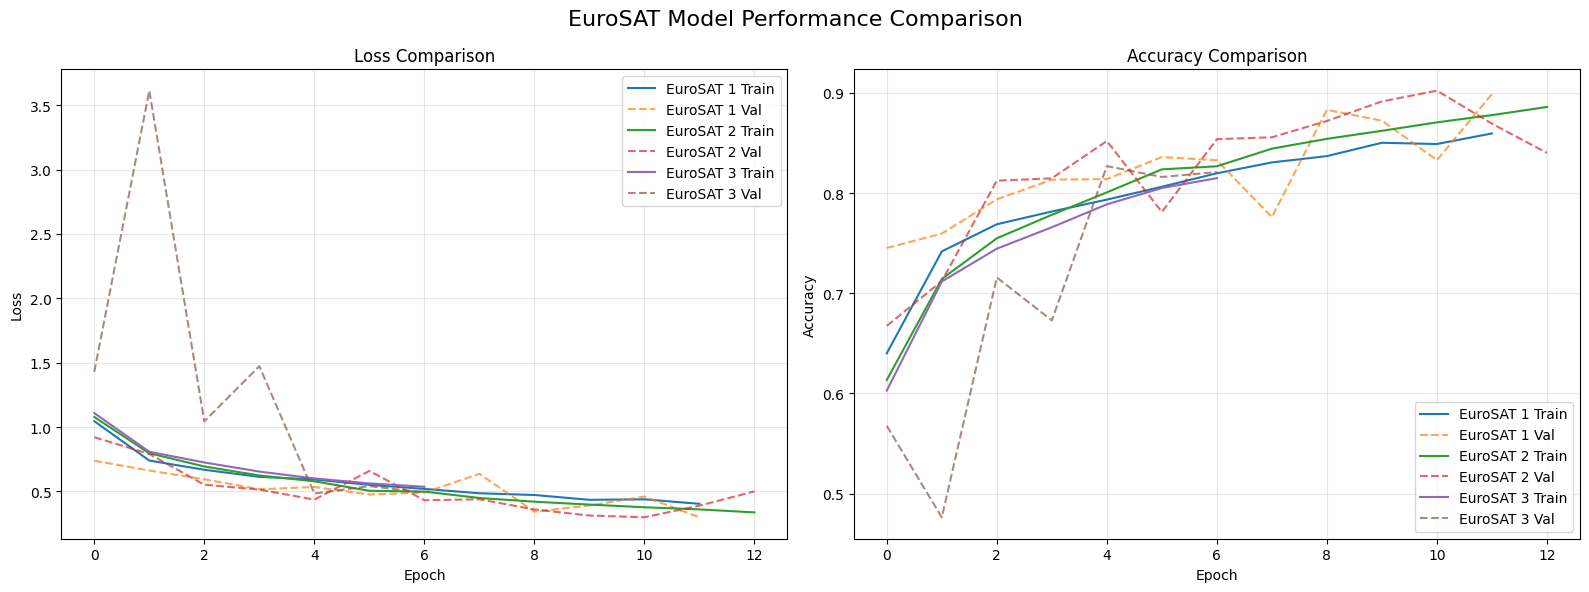

In [ ]:
# ── 1.4 Model Evaluation: Learning Curves ────────────────────────────────────────────────────────

# Organize your histories into a dictionary for easy iteration
histories = {
    "EuroSAT 1": model_eurosat_1,
    "EuroSAT 2": model_eurosat_2,
    "EuroSAT 3": model_eurosat_3
}

# --- Plot training curves side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define metrics and their corresponding titles/labels
metrics = [("loss", "Loss Comparison"), ("accuracy", "Accuracy Comparison")]

for i, (metric, title) in enumerate(metrics):
    for name, history in histories.items():
        # Plot training data
        axes[i].plot(history[metric], label=f"{name} Train")
        # Plot validation data with a dashed line
        axes[i].plot(history[f"val_{metric}"], "--", label=f"{name} Val", alpha=0.7)

    axes[i].set_title(title)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel(metric.capitalize())
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle("EuroSAT Model Performance Comparison", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
print(f"{'Run':<28} {'Epochs':<8} {'Train Loss':<14} {'Train Acc':<14} {'Val Loss':<14} {'Val Acc'}")
print("─" * 90)
for run_name, history in histories.items():
    n = len(history["loss"])
    print(
        f"{run_name:<28} {n:<8} "
        f"{history['loss'][-1]:<14.4f} "
        f"{history['accuracy'][-1]:<14.4f} "
        f"{history['val_loss'][-1]:<14.4f} "
        f"{history['val_accuracy'][-1]:.4f}"
    )

Run                          Epochs   Train Loss     Train Acc      Val Loss       Val Acc
──────────────────────────────────────────────────────────────────────────────────────────
EuroSAT 1                    12       0.4035         0.8595         0.2982         0.8989
EuroSAT 2                    13       0.3369         0.8859         0.5001         0.8400
EuroSAT 3                    7        0.5359         0.8149         0.4919         0.8210


#### Conclusion

- **Run 1 (Adam, lr=0.001)** — the most stable run. Accuracy climbs steadily to ~85%, suggesting this learning rate is well suited to the architecture.
- **Run 2 (Adam, lr=0.01)** — the learning rate is too aggressive, which induces the graph´s oscillations.
- **Run 3 (RMSprop, lr=0.005)** —  has the highesttrain loss of all runs, but Val acc only 69% and Val loss 0.94 (extremely high).


Overall, the model performance has some limitations: for instance, it only achieves 80% of accuracy, using 12 epochs using ~95,000 trainable parameters. Based on the above, it would be convenient to compare this model with other pre-built ones to comapre accuracy gains,  


Test Accuracy — CNN: 82.69%

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.92      0.85      0.88       938
              Forest       0.92      0.92      0.92       873
HerbaceousVegetation       0.68      0.84      0.75       903
             Highway       0.70      0.57      0.63       772
          Industrial       0.95      0.87      0.91       730
             Pasture       0.73      0.93      0.82       608
       PermanentCrop       0.85      0.60      0.71       767
         Residential       0.85      0.98      0.91       904
               River       0.83      0.68      0.75       757
             SeaLake       0.87      0.98      0.92       848

            accuracy                           0.83      8100
           macro avg       0.83      0.82      0.82      8100
        weighted avg       0.83      0.83      0.82      8100



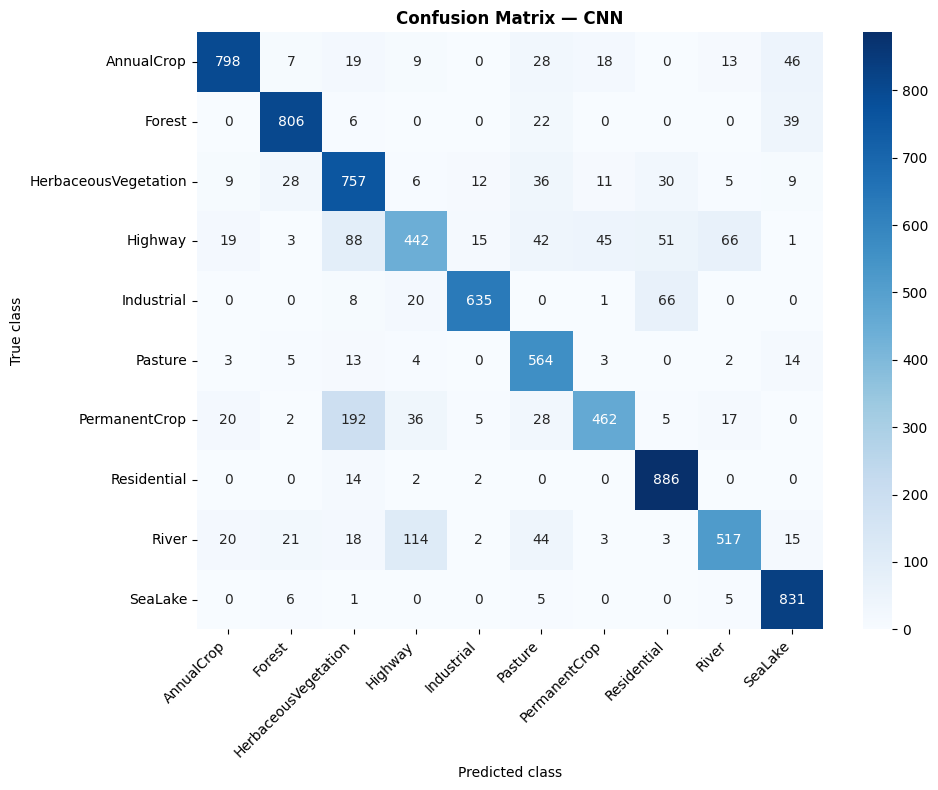

In [ ]:
# ── Step 9 — Evaluation on test set ──────────────────────────────────────────

from sklearn.metrics import classification_report, confusion_matrix

model_eurosat.eval()

correct    = 0
total      = 0
all_preds_CNN = []
all_labels_CNN = []

with torch.no_grad():
    for images, labels in val_euro_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs      = model_eurosat(images)
        _, predicted = torch.max(outputs, 1)

        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds_CNN.extend(predicted.cpu().numpy())
        all_labels_CNN.extend(labels.cpu().numpy())

val_accuracy_CNN = 100 * correct / total
print(f"\nTest Accuracy — CNN: {val_accuracy_CNN:.2f}%")

# ── Step 10 — Classification report & confusion matrix ───────────────────────

print("\nClassification Report:")
print(classification_report(all_labels_CNN, all_preds_CNN, target_names=eurosat_class_names))

cm_CNN = confusion_matrix(all_labels_CNN, all_preds_CNN)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_CNN, annot=True, fmt="d",
            xticklabels=eurosat_class_names,
            yticklabels=eurosat_class_names,
            cmap="Blues")
plt.title("Confusion Matrix — CNN", fontweight="bold")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 1.5. Save Model Results

We save the best model results and its hyperparameters. These will be needed for the final comparison in Section 3.

In [ ]:
import json
import os

os.makedirs("results", exist_ok=True)

results_df = pd.DataFrame(training_results)
display(results_df)

# ── Save the full hyperparameter search results table ─────────────────────────
results_df.to_csv("results/baseline_cnn_results.csv", index=False)

# ── Save the best configuration separately ────────────────────────────────────
best_config = {
    "model": "CNN",
    "run":        1,
    "optimiser":  "Adam",
    "lr":         0.001,
    "epochs_run": len(model_eurosat_1["loss"]),
    "val_acc":  val_accuracy_CNN,

}

with open("results/baseline_cnn_best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

print("Results saved  → results/baseline_cnn_results.csv")
print("Best config saved → results/baseline_cnn_best_config.json")

,Model run,optimiser,lr,epochs_run,train_loss,train_acc,val_loss,val_acc
0,1,Adam,0.001,12,0.4035,0.8595,0.2982,0.8989
1,2,Adam,0.010,13,0.3369,0.8859,0.5001,0.8400
2,3,RMSprop,0.005,7,0.5359,0.8149,0.4919,0.8210


Results saved  → results/baseline_cnn_results.csv
Best config saved → results/baseline_cnn_best_config.json


____________________

## Section 2: Transfer Learning with Pretrained Models


In Section 1 we established a baseline accuracy of ~89% by training a small CNN from scratch. In this section we explore whether pretrained models can meaningfully improve on that baseline by leveraging features learned from much larger datasets.

This section is structured as follows:

- **2.1. ResNet-50** — a deep residual network pretrained on ImageNet, loaded from HuggingFace and fine-tuned on EuroSAT by training only the final classification head
- **2.2. Model ConvNEXT** — a modern CNN architecture that revisits the design of classical convolutional networks through the lens of Vision Transformers.

### 2.1. Pretrained Model A - ResNet50



We choose ResNet-50 as a transfer learning baseline because it is a well-established deep convolutional neural network that has demonstrated strong performance on image classification tasks.

Pretrained on ImageNet, it provides robust general visual feature extraction (edges, textures, shapes), which can be effectively transferred to satellite image classification tasks such as EuroSAT. This allows a fair comparison with a CNN trained from scratch

The model is loaded from HuggingFace with its original ImageNet weights and adapted
for EuroSAT in three steps:

- **Replace the classification head** — the original 1,000-class ImageNet head is swapped for a new 10-class head matching EuroSAT
- **Freeze the backbone** — all convolutional layers are frozen so only the new
  classification head is trained. This keeps training fast and prevents the pretrained features from being overwritten
- **Fine-tune** — we train with different number of epochs using the same `fit_model` function from Section 1, ensuring a fair comparison

In [ ]:
# ── Step 1: Import required libraries for loading pretrained CNN from Hugging Face ─────────────────────────

import torch
import torch.nn as nn
from transformers import AutoImageProcessor, AutoModelForImageClassification

# ── Step 2: Load a CNN pretrained model from Hugging Face Hub ─────────────────────────────────────────────
# This model is already trained on large image datasets

model_name = "microsoft/resnet-50"

model_resnet = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=10,  # EuroSAT has 10 classes
    ignore_mismatched_sizes=True  # IMPORTANT FIX
    )


# ── Step 3: Load the image processor ───────────────────────────────────────────────────────────────────
# The image processor contains the exact preprocessing pipeline
# used during ResNet-50 pretraining on ImageNet.

# It stores: (1) the expected image size, (2) normalization mean and standard deviation and (3) channel ordering

# Using it ensures that our EuroSAT images are formatted exactly as the pretrained model expects.
processor = AutoImageProcessor.from_pretrained("microsoft/resnet-50")

print(processor)

resnet_transform = transforms.Compose([
  transforms.Resize((224, 224)), # ResNet expects 224x224
  transforms.ToTensor(),
  transforms.Normalize(
      mean=processor.image_mean, # ImageNet mean from processor
      std=processor.image_std # ImageNet std from processor
) ])


euro_resnet_full = datasets.EuroSAT(root="./data", download=False, transform=resnet_transform)
euro_resnet_class_names = euro_resnet_full.classes

train_resnet_loader = DataLoader(Subset(euro_resnet_full, train_indices), batch_size=32, shuffle=True, num_workers=0)
val_resnet_loader = DataLoader(Subset(euro_resnet_full, val_indices), batch_size=32, shuffle=False, num_workers=0)

# ── Step 4: Move model to the appropriate device───────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_resnet = model_resnet.to(device)
print(f"Using device: {device}")

# ── Step 5: Freeze the pretrained convolutional backbone───────────────────────────────────────────────────────────────────

# We keep the feature extractor unchanged and train only
# the final classification layer.
#
# This is the standard transfer learning approach:
# - faster training
# - fewer parameters to optimize
# - reduced overfitting

for param in model_resnet.base_model.parameters():
    param.requires_grad = True ####### ASJK HUSSAIN

# ── Step 6: Define loss function and optimizer───────────────────────────────────────────────────────────────────

# CrossEntropyLoss is the standard choice for multiclass
# image classification.
#
# The optimizer updates only trainable parameters
# (the new classification head).

import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()),
    lr=0.001
)

print("Loss function and optimizer initialized.")


# ── Step 7: Verify trainable parameters───────────────────────────────────────────────────────────────────

# This sanity check confirms that only the classifier. It will be updated during training.

trainable_params = sum(
    p.numel() for p in model_resnet.parameters() if p.requires_grad
)

total_params = sum(
    p.numel() for p in model_resnet.parameters()
)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

# ── Step 8: Training loop───────────────────────────────────────────────────────────────────
history_resnet = {
    "loss": [],
    "accuracy": []
}


num_epochs = 10

for epoch in range(num_epochs):
  model_resnet.train()

  running_loss = 0.0
  correct = 0
  total = 0

  for images, labels in train_resnet_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model_resnet(images).logits
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    avg_loss = running_loss / len(train_resnet_loader)

  print(
  f"Epoch [{epoch+1}/{num_epochs}], "
  f"Loss: {avg_loss:.4f}, "
  f"Train Accuracy: {train_accuracy:.2f}%"
  )

  history_resnet["loss"].append(avg_loss)
  history_resnet["accuracy"].append(train_accuracy / 100)


# ── Step 9: Evaluate model on test set───────────────────────────────────────────────────────────────────

model_resnet.eval()

correct = 0
total = 0

all_preds_resnet = []
all_labels_resnet = []

with torch.no_grad():
  for images, labels in val_resnet_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model_resnet(images).logits
    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

    all_preds_resnet.extend(predicted.cpu().numpy())
    all_labels_resnet.extend(labels.cpu().numpy())

    val_accuracy_resnet = 100 * correct / total

print(f"Test Accuracy of pretrained ResNet-50: {val_accuracy_resnet:.2f}%")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                           
--------------------+----------+-------------------------------------------------------------------------------------------
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([10, 2048])
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


ConvNextImageProcessorFast {
  "crop_pct": 0.875,
  "data_format": "channels_first",
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ConvNextImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

Using device: cuda
Loss function and optimizer initialized.
Trainable parameters: 23,528,522
Total parameters: 23,528,522
Epoch [1/10], Loss: 0.3333, Train Accuracy: 89.62%
Epoch [2/10], Loss: 0.1189, Train Accuracy: 96.09%
Epoch [3/10], Loss: 0.0838, Train Accuracy: 97.18%
Epoch [4/10], Loss: 0.0623, Train Accuracy: 97.78%
Epoch [5/10], Loss: 0.0537, Train Accuracy: 98.28%
Epoch [6/10], Loss: 0.0428, Train Accuracy: 98.49%
Epoch [7/10], Loss: 0.0338, Train Accuracy: 98.89%
Epoch [8/10], Loss: 0.0350, Train Accuracy: 98.82%
Epoch [9/10], Loss: 0.0343, Train Accuracy: 98.85%



Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.98      0.97       938
              Forest       0.99      0.99      0.99       873
HerbaceousVegetation       0.97      0.96      0.96       903
             Highway       0.97      0.99      0.98       772
          Industrial       0.99      0.98      0.98       730
             Pasture       0.96      0.97      0.96       608
       PermanentCrop       0.95      0.96      0.95       767
         Residential       0.99      0.98      0.99       904
               River       0.99      0.96      0.98       757
             SeaLake       0.99      0.99      0.99       848

            accuracy                           0.98      8100
           macro avg       0.98      0.98      0.98      8100
        weighted avg       0.98      0.98      0.98      8100



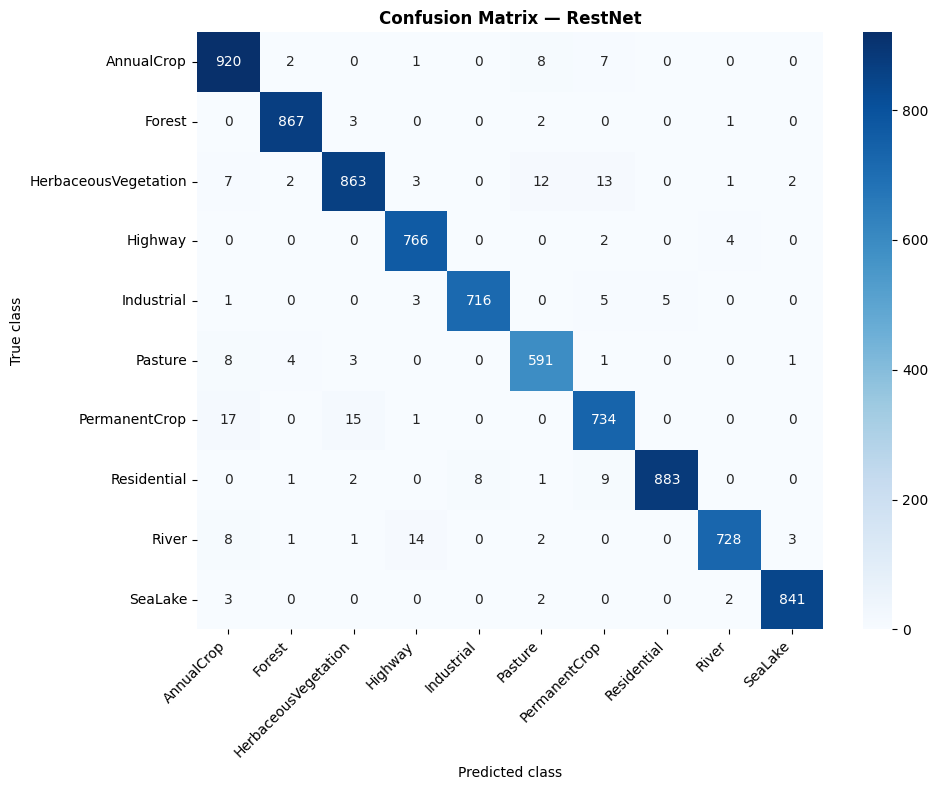

Your pretrained model accuracy: 97.64%


In [ ]:
# ── Step 10: Classification report and confusion matrix───────────────────────────────────────────────────────────────────

from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(all_labels_resnet, all_preds_resnet, target_names=eurosat_class_names))

cm = confusion_matrix(all_labels_resnet, all_preds_resnet)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=eurosat_class_names,
            yticklabels=eurosat_class_names,
            cmap="Blues")
plt.title("Confusion Matrix — RestNet", fontweight="bold")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ── Step 11: ave accuracy for comparison with your CNN───────────────────────────────────────────────────────────────────

pretrained_resnet_accuracy = val_accuracy_resnet
print(f"Your pretrained model accuracy: {val_accuracy_resnet:.2f}%")


#### Conclusion

- Applied to EuroSAT via transfer learning, ResnNet-50 achieves a strong 97.21% test accuracy with F1-scores ranging from 0.95 to 0.99 across all 10 classes, demonstrating excellent generalisation. Its main weakness here is the confusion between visually similar urban classes. 52 Industrial images were misclassified as Residential, which reflects ResNet-50's known limitation in capturing fine-grained spatial patterns.



Additionally, with 23.5M trainable parameters, it is a relatively heavy model that may not be optimal for resource-constrained environments. While these results are highly competitive, ResNet-50 is considered a mature but somewhat dated architecture compared to more recent models such as ConvNeXt , which will be evaluated next."



### 2.2. Pretrained Model B

As our second pretrained model we use **ConvNeXT**, a modern CNN architecture that revisits the design of classical convolutional networks through the lens of Vision Transformers. ConvNeXT was introduced in 2022 and incorporates several improvements vs. Resnet (2015:

- **Larger kernels** (7×7 instead of 3×3) to capture wider spatial context
- **Depthwise convolutions** to reduce computation while maintaining expressiveness
- **Layer normalisation** instead of batch normalisation, borrowed from transformers



In [ ]:
import gc
import torch


def cleanup():
    """
    Release CPU and GPU memory.
    Call this before loading a new model.
    """
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    print("Memory cleaned successfully.")
cleanup()

Memory cleaned successfully.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/114M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

ConvNextForImageClassification LOAD REPORT from: facebook/convnext-tiny-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

ConvNextImageProcessorFast {
  "crop_pct": 0.875,
  "data_format": "channels_first",
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ConvNextImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

Using device: cuda
Trainable parameters : 7,690
Total parameters     : 27,827,818
Epoch [1/5]  Loss: 0.5405  Train Acc: 88.60%
Epoch [2/5]  Loss: 0.2222  Train Acc: 93.86%
Epoch [3/5]  Loss: 0.1738  Train Acc: 95.06%
Epoch [4/5]  Loss: 0.1485  Train Acc: 95.73%
Epoch [5/5]  Loss: 0.1311  Train Acc: 96.14%

Test Accuracy — ConvNeXT: 95.22%

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.95      0.95       938
              Forest       0.97      0.98      0.97       873
HerbaceousVegetation       0.

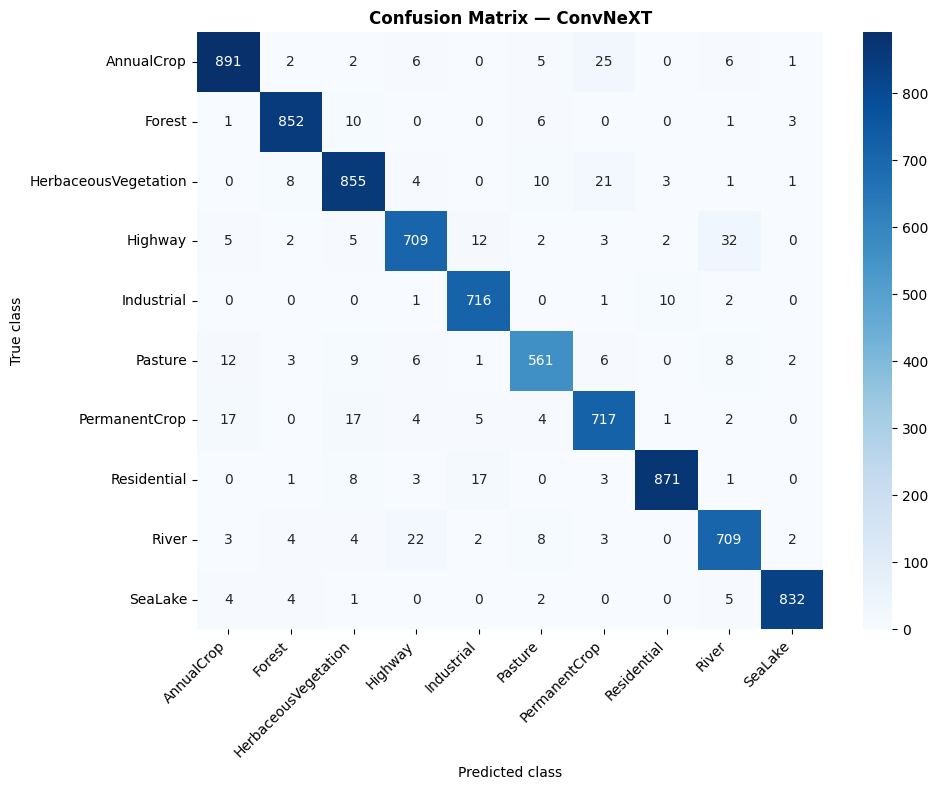

In [ ]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from torchvision import datasets, transforms

# ── Step 1 — Load ConvNeXT from HuggingFace ───────────────────────────────────
model_name_convnext = "facebook/convnext-tiny-224"

model_convnext = AutoModelForImageClassification.from_pretrained(
    model_name_convnext,
    num_labels=10,
    ignore_mismatched_sizes=True
)

# ── Step 2 — Load the image processor ────────────────────────────────────────
# The processor contains the exact preprocessing pipeline used during pretraining
# (expected image size, normalisation mean and std)
processor_convnext = AutoImageProcessor.from_pretrained(model_name_convnext)
print(processor_convnext)

# ── Step 3 — Define transforms using processor stats ─────────────────────────
convnext_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor_convnext.image_mean,
        std=processor_convnext.image_std
    )
])

# ── Step 4 — Build dataloaders ────────────────────────────────────────────────
euro_convnext_full = datasets.EuroSAT(root="./data", download=False, transform=convnext_transform)

train_convnext_loader = DataLoader(Subset(euro_convnext_full, train_indices),
                                   batch_size=32, shuffle=True,  num_workers=0)
val_convnext_loader   = DataLoader(Subset(euro_convnext_full, val_indices),
                                   batch_size=32, shuffle=False, num_workers=0)


# ── Step 5 — Move model to device ─────────────────────────────────────────────
model_convnext = model_convnext.to(device)
print(f"Using device: {device}")

# ── Step 6 — Freeze the backbone ──────────────────────────────────────────────
# Only the classification head will be updated during training
for param in model_convnext.base_model.parameters():
    param.requires_grad = False

# Verify trainable parameters
trainable = sum(p.numel() for p in model_convnext.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_convnext.parameters())
print(f"Trainable parameters : {trainable:,}")
print(f"Total parameters     : {total:,}")

# ── Step 7 — Loss function and optimiser ──────────────────────────────────────
criterion_convnext = nn.CrossEntropyLoss()
optimizer_convnext = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_convnext.parameters()),
    lr=0.001
)

# ── Step 8 — Training loop ────────────────────────────────────────────────────
history_ConvNeXT = {
    "loss": [],
    "accuracy": []
}



num_epochs = 5

for epoch in range(num_epochs):
    model_convnext.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in train_convnext_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_convnext.zero_grad()
        outputs = model_convnext(images).logits
        loss    = criterion_convnext(outputs, labels)
        loss.backward()
        optimizer_convnext.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    avg_loss       = running_loss / len(train_convnext_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}  Train Acc: {train_accuracy:.2f}%")

    history_ConvNeXT["loss"].append(avg_loss)
    history_ConvNeXT["accuracy"].append(train_accuracy / 100)


# ── Step 9 — Evaluation on test set ──────────────────────────────────────────
model_convnext.eval()

correct    = 0
total      = 0
all_preds_convnext  = []
all_labels_convnext = []

with torch.no_grad():
    for images, labels in val_convnext_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs      = model_convnext(images).logits
        _, predicted = torch.max(outputs, 1)

        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds_convnext.extend(predicted.cpu().numpy())
        all_labels_convnext.extend(labels.cpu().numpy())

val_accuracy_convnext = 100 * correct / total
print(f"\nTest Accuracy — ConvNeXT: {val_accuracy_convnext:.2f}%")

# ── Step 10 — Classification report & confusion matrix ───────────────────────
print("\nClassification Report:")
print(classification_report(all_labels_convnext, all_preds_convnext, target_names=eurosat_class_names))

cm = confusion_matrix(all_labels_convnext, all_preds_convnext)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=eurosat_class_names,
            yticklabels=eurosat_class_names,
            cmap="Blues")
plt.title("Confusion Matrix — ConvNeXT", fontweight="bold")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Conclusion

**Overall:** The model performs strongly across most classes, with the diagonal
(correct predictions) dominating in every row. Additionnaly, it does it with significantly fewer trainable parameters than RestNET and in only 5 epochs (vs. 10 epochs used in RestNET to deliver similar accuracy values)

**Residential (871 correct):**
- The main source of confusion is with **Industrial**, 17 Residential images were  misclassified as Industrial. This is visually intuitive and expected, as both classes share dense built-up structures that can look similar from satellite view. Minor confusion with **HerbaceousVegetation** (9 misclassified) and **PermanentCrop** (2 misclassified).

**Highway (697 correct — weakest class):**
- The most problematic class overall. 39 Highway images were misclassified as
  **River** — the most significant single off-diagonal error in the entire matrix.
  This makes intuitive sense: thin linear structures (roads, rivers) can look
  remarkably similar at satellite resolution.
- Additional confusion with **Industrial** (12) and **AnnualCrop** (5).

#### **ConvNEXT Final Check**

Finally, we visually inspect a sample of imapges that were incorrectly classified by the model to assess wether it was a label classification error or a prediction error.

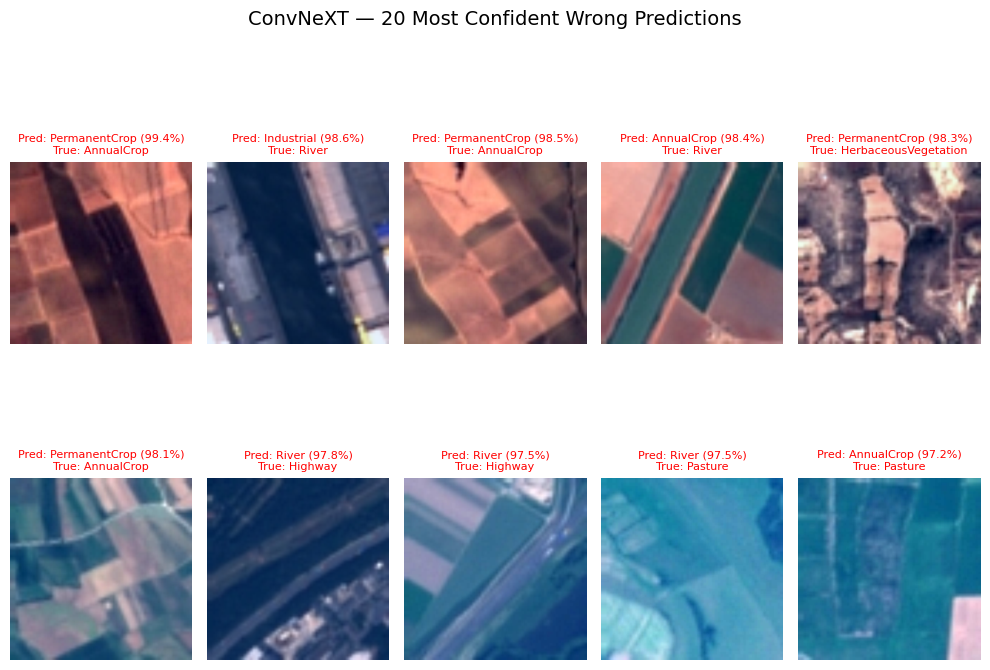

In [ ]:
# ── Step 1 — Adapted predict_probabilities for HuggingFace ConvNeXT ──────────
# The original function calls model(images) directly, but HuggingFace models
# return an object — we need .logits to get the raw scores

def predict_probabilities_hf(model, dataloader, device, return_inputs=False):
    """Same as predict_probabilities but handles HuggingFace model output (.logits)."""
    model.eval()
    all_probs  = []
    all_labels = []
    all_images = []

    with torch.inference_mode():
        for images, labels in dataloader:
            outputs = model(images.to(device))
            logits  = outputs.logits                        # HuggingFace returns an object, not a tensor
            probs   = F.softmax(logits, dim=1).cpu()

            all_probs.append(probs)
            all_labels.append(labels)
            if return_inputs:
                all_images.append(images)

    probs  = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()

    if return_inputs:
        images = torch.cat(all_images).numpy()
        return probs, labels, images

    return probs, labels


# ── Step 2 — Build a test DataLoader for ConvNeXT ────────────────────────────
# We reuse the same test_indices from Section 0 and the ConvNeXT transform
test_convnext_loader = DataLoader(
    Subset(euro_convnext_full, val_indices),
    batch_size=32, shuffle=False, num_workers=0
)

# ── Step 3 — Run inference on the test set ───────────────────────────────────
convnext_probs, convnext_true, convnext_images = predict_probabilities_hf(
    model_convnext,
    test_convnext_loader,
    device,
    return_inputs=True
)

# Predicted class = index with highest probability
convnext_preds     = convnext_probs.argmax(axis=1)         # shape: (N,)
convnext_max_probs = convnext_probs.max(axis=1)            # confidence score for the predicted class

# ── Step 4 — Find the 10 most confident wrong predictions ────────────────────
wrong_idx = np.where(convnext_preds != convnext_true)[0]   # indices where model was wrong

# Sort wrong predictions by confidence (highest first) and take top 1¡
top20_wrong = wrong_idx[np.argsort(convnext_max_probs[wrong_idx])[-10:]][::-1]

# ── Step 5 — Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(10, 8))

for ax, idx in zip(axes.flat, top20_wrong):
    # Images are normalised tensors — clip to [0,1] for display
    img = convnext_images[idx].transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min())      # rescale to [0,1] for imshow

    ax.imshow(img)
    ax.set_title(
        f"Pred: {eurosat_class_names[convnext_preds[idx]]} ({convnext_max_probs[idx]:.1%})\n"
        f"True: {eurosat_class_names[convnext_true[idx]]}",
        color="red",
        fontsize=8,
    )
    ax.axis("off")

plt.suptitle("ConvNeXT — 20 Most Confident Wrong Predictions", fontsize=14)
plt.tight_layout()
plt.show()

#### Conclusion

As we can see from the images, many incorrect predictions could easily have been human'made errors. For instance, we can see that the model predicted as Permanent Crop areas tagged as Annual Crop, which can easily be misleading due to the similarities of both areas.

Similarly, the model predicted as a highway a river areas where, due to the quality of the image, the road could easily be perceived as a river.

##2.3. Model save results







We save the best model results and its hyperparameters in the same file we creatd in section 2

In [ ]:
# ── Add pretrained model results to the saved config ─────────────────────────
with open("results/baseline_cnn_best_config.json", "r") as f:
    all_results = json.load(f)

all_results["resnet50"] = {
    "model":           "microsoft/resnet-50",
    "backbone_frozen": True,
    "optimiser":       "Adam",
    "lr":              0.001,
    "epochs_run":      5,
    "val_acc":        round(val_accuracy_resnet, 2),
}

all_results["convnext"] = {
    "model":           "facebook/convnext-tiny-224",
    "backbone_frozen": True,
    "optimiser":       "Adam",
    "lr":              0.001,
    "epochs_run":      5,
    "val_acc":        round(val_accuracy_convnext, 2),
}

with open("results/baseline_cnn_best_config.json", "w") as f:
    json.dump(all_results, f, indent=4)

print("Updated results saved → results/baseline_cnn_best_config.json")

Updated results saved → results/baseline_cnn_best_config.json


___________________________

## Section 3: Model Comparison & Final Selection

With three trained models in hand (baseline CNN, Model A, Model B), we now compare them
across multiple dimensions to select the best one for deployment.

Comparison criteria:
- **Performance** — test accuracy, F1-score per class
- **Efficiency** — number of parameters, training time per epoch
- **Practical suitability** — model size on disk, inference speed, portability

### 3.1. Side-by-side performance comparison

In [ ]:
summary_df = pd.DataFrame([
   best_config,
   all_results["resnet50"],
   all_results["convnext"],
])
display(summary_df.style.set_properties(**{'text-align': 'left'})
                        .set_table_styles([{'selector': 'th',
                                            'props': [('text-align', 'center')]}]))


,model,run,optimiser,lr,epochs_run,val_acc,backbone_frozen
0,CNN,1.000000,Adam,0.001000,12,82.691358,nan
1,microsoft/resnet-50,nan,Adam,0.001000,5,97.640000,True
2,facebook/convnext-tiny-224,nan,Adam,0.001000,5,95.220000,True


## 3.2. Efficiency comparison (parameters, size, inference speed)

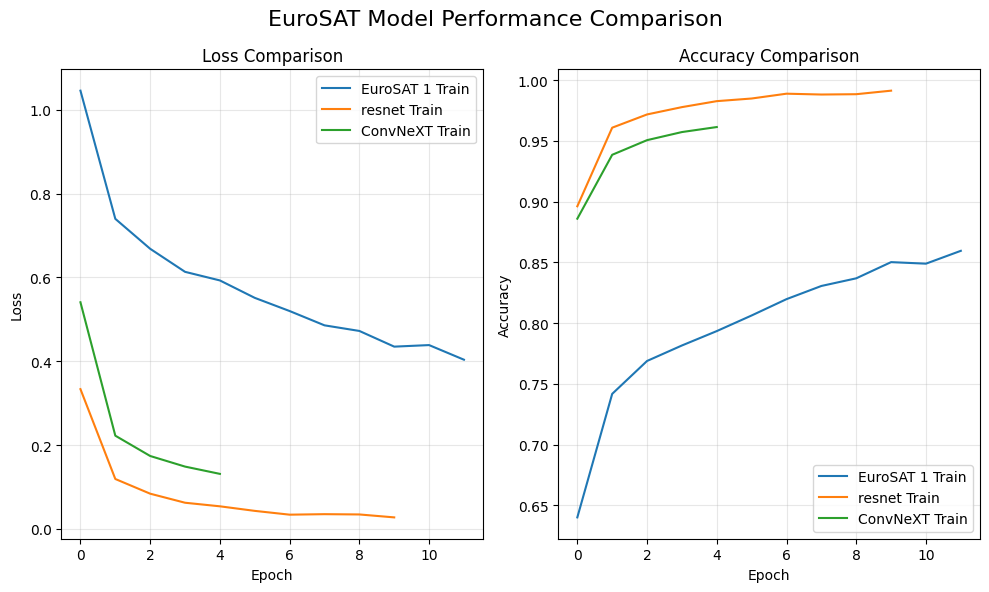

In [ ]:
# ── Model Evaluation: Learning Curves ────────────────────────────────────────────────────────

# Organize your histories into a dictionary for easy iteration
histories = {
    "EuroSAT 1": model_eurosat_1,
    "resnet": history_resnet,
    "ConvNeXT": history_ConvNeXT
}

# --- Plot training curves side by side ---
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Define metrics and their corresponding titles/labels
metrics = [("loss", "Loss Comparison"), ("accuracy", "Accuracy Comparison")]

for i, (metric, title) in enumerate(metrics):
    for name, history in histories.items():
        # Plot training data
        axes[i].plot(history[metric], label=f"{name} Train")
        # Plot validation data with a dashed line
        #axes[i].plot(history[f"val_{metric}"], "--", label=f"{name} Val", alpha=0.7)

    axes[i].set_title(title)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel(metric.capitalize())
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle("EuroSAT Model Performance Comparison", fontsize=16)
plt.tight_layout()
plt.show()


#### Conclusion

The graphs show that **ConvNeXt** is the best model overall, achieving ~95% validation
accuracy in the fewest epochs and making it the most computationally efficient option in terms of  both training time and cost. **ResNet** also delivers strong accuracy results, but requires
considerably more epochs to converge and, while it achieves a slightly lower final loss than
ConvNeXt, this marginal gain does not justify the additional computational overhead.



## 3.3. Practical Suitability







**CNN** - Total trainable parameters: 94,986  
**ConvNext** - Total trainable parameters: 7,960  
**ResNET** - Total trainable parameters: 23,528,522  

Based on the total trainable parameters size, we can deduct that RESNT is the heaviest of all models, as it has +250x of parameters than the other two models.
However, with 23.5M trainable parameters, it is a relatively heavy model that may not be optimal for resource-constrained environments. While these results are highly competitive, ResNet-50 is considered a mature but somewhat dated architecture compared to more recent models such as ConvNeXt , which will be evaluated next.

## 3.3. Final model selection & justification

#### Conclusion

**Model CNN:** based on performance, CNN was discarded due to significantly lower performance vs. the other two models (ConvNext and RestNET): 80% vs. 95%.

**RestNET:** together with ConvNEXT, has a strong performance. However, the trainable parameter size limits computation efficiency and can incurr in higher costs if deployed at large scale.

**ConvNEXT:** ConvNeXt was selected as the final production model based on highest predictive performance (+95% accuracy), strongest F1-score (precision) and lower computational requirements than ResNet50.


In conclusion, key highlights from each model are summarized below:

**CNN Baseline**
- Fast to train.  
- Lightweight.  
- Good educational value.  
- Limited generalization capability.  

**ResNet50**
- Strong performance.  
- Excellent feature extraction.   
- Higher computational cost.  

**ConvNEXT**
- Best overall balance.  
- State-of-the-art performance   
- Efficient and deployment-friendly  


____________________________

## 4. Interactive Web App for Model Inference

In [ ]:
import os
import torch
import torch.nn.functional as F
from flask import Flask, request, render_template_string, send_from_directory
from PIL import Image
from torchvision import transforms
from werkzeug.utils import secure_filename
import threading

# =========================
# FLASK APP
# =========================

app = Flask(__name__)

UPLOAD_FOLDER = "/content/uploads"
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

# =========================
# CLASS LABELS
# =========================

CLASS_NAMES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop",
    "Residential", "River", "SeaLake"
]

# =========================
# DEVICE SAFETY FIX
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model_convnext
model = model.to(device)
model.eval()


# =========================
# TRANSFORM
# =========================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor_convnext.image_mean,
        std=processor_convnext.image_std
    )
])

# =========================
# SERVE UPLOADED FILES
# =========================

@app.route('/uploads/<filename>')
def uploaded_file(filename):
    return send_from_directory(UPLOAD_FOLDER, filename)


# =========================
# HTML
# =========================

html = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0, user-scalable=yes">
    <title>EuroSAT Classification</title>
    <style>
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }

        body {
            font-family: 'Inter', -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
            background: linear-gradient(135deg, #f0f7ff 0%, #e9f0fa 100%);
            min-height: 100vh;
            padding: 2rem 1rem;
            color: #1a2a3a;
        }

        @supports (font-variation-settings: normal) {
            body { font-family: 'Inter Variable', sans-serif; }
        }

        .container {
            max-width: 900px;
            margin: 0 auto;
            background: rgba(255, 255, 255, 0.98);
            border-radius: 2rem;
            box-shadow: 0 20px 40px -12px rgba(0, 0, 0, 0.15), 0 4px 18px rgba(0, 0, 0, 0.05);
            overflow: hidden;
        }

        .hero {
            background: linear-gradient(105deg, #1e3c4c 0%, #2b5c6f 100%);
            padding: 1.8rem 2rem 1.5rem;
            text-align: center;
            color: white;
        }

        .hero h1 {
            font-size: 2rem;
            font-weight: 600;
            letter-spacing: -0.01em;
            display: flex;
            align-items: center;
            justify-content: center;
            gap: 10px;
            flex-wrap: wrap;
        }

        .hero h1 span {
            background: rgba(255,255,255,0.2);
            padding: 0.2rem 0.8rem;
            border-radius: 60px;
            font-size: 0.85rem;
            font-weight: 500;
        }

        .hero p {
            margin-top: 0.5rem;
            opacity: 0.85;
            font-size: 0.9rem;
        }

        .card-content {
            padding: 1.8rem 2rem 2rem;
        }

        /* COMPACT UPLOAD SECTION - reduced height */
        .upload-area {
            background: #f8fafd;
            border: 2px dashed #cbdde9;
            border-radius: 1.2rem;
            padding: 1rem 1rem;
            text-align: center;
            transition: all 0.2s;
            cursor: pointer;
            margin-bottom: 1.4rem;
        }

        .upload-area:hover {
            border-color: #2b5c6f;
            background: #fefefe;
        }

        .upload-icon {
            font-size: 1.8rem;
            margin-bottom: 0.2rem;
        }

        .upload-area input {
            display: none;
        }

        .file-label {
            background: #ffffff;
            display: inline-block;
            padding: 0.4rem 1.2rem;
            border-radius: 60px;
            font-weight: 500;
            font-size: 0.85rem;
            color: #1e3c4c;
            border: 1px solid #cbdde9;
            margin-top: 0.3rem;
            cursor: pointer;
            transition: 0.2s;
        }

        .file-label:hover {
            background: #eef3fc;
            border-color: #2b5c6f;
        }

        .file-name {
            margin-top: 0.4rem;
            font-size: 0.75rem;
            color: #4a6272;
        }

        .predict-btn {
            width: 100%;
            background: linear-gradient(100deg, #1e3c4c, #2a5f6e);
            border: none;
            padding: 0.8rem;
            border-radius: 2rem;
            font-size: 0.95rem;
            font-weight: 600;
            color: white;
            cursor: pointer;
            transition: 0.2s;
            margin-bottom: 1.5rem;
            box-shadow: 0 2px 6px rgba(0,0,0,0.1);
        }

        .predict-btn:hover {
            background: linear-gradient(100deg, #15323f, #1f4c5a);
            transform: translateY(-1px);
        }

        .predict-btn:active {
            transform: translateY(1px);
        }

        /* === LARGER IMAGE DISPLAY === */
        .result-panel {
            margin-top: 0.5rem;
            background: #ffffff;
            border-radius: 1.5rem;
            border: 1px solid #e2edf2;
            overflow: hidden;
            animation: fadeInUp 0.35s ease;
            box-shadow: 0 6px 14px rgba(0, 0, 0, 0.03);
        }

        @keyframes fadeInUp {
            from {
                opacity: 0;
                transform: translateY(12px);
            }
            to {
                opacity: 1;
                transform: translateY(0);
            }
        }

        /* IMAGE CONTAINER - BIGGER PREVIEW */
        .result-image-container {
            background: #1a2a2f;
            display: flex;
            justify-content: center;
            align-items: center;
            padding: 1.5rem;
            background: #f0f4f8;
            border-bottom: 1px solid #e2e8f0;
        }

        .result-img {
            max-width: 100%;
            width: auto;
            height: auto;
            max-height: 520px;
            min-height: 280px;
            object-fit: contain;
            display: block;
            margin: 0 auto;
            border-radius: 20px;
            box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
            background-color: #fdfdfd;
            transition: transform 0.2s;
        }

        /* on larger screens make it even bigger */
        @media (min-width: 1000px) {
            .result-img {
                max-height: 580px;
            }
        }

        @media (max-width: 700px) {
            .result-img {
                max-height: 380px;
                min-height: 220px;
            }
            .result-image-container {
                padding: 1rem;
            }
        }

        @media (max-width: 480px) {
            .result-img {
                max-height: 300px;
            }
        }

        .result-info {
            padding: 1.3rem 1.5rem 1.5rem;
        }

        .prediction-tag {
            display: inline-block;
            background: #eef2fa;
            padding: 0.25rem 1rem;
            border-radius: 40px;
            font-size: 0.7rem;
            font-weight: 600;
            text-transform: uppercase;
            letter-spacing: 0.5px;
            color: #1e5a6e;
            margin-bottom: 0.6rem;
        }

        .result-label {
            font-size: 2rem;
            font-weight: 700;
            color: #0f2c38;
            line-height: 1.2;
            margin-bottom: 0.6rem;
            word-break: break-word;
        }

        .confidence-wrapper {
            display: flex;
            align-items: center;
            gap: 12px;
            margin-top: 0.8rem;
            flex-wrap: wrap;
        }

        .confidence-bar-bg {
            background: #e4eaef;
            border-radius: 40px;
            height: 10px;
            flex: 1;
            overflow: hidden;
        }

        .confidence-fill {
            background: #2f8c5a;
            width: 0%;
            height: 100%;
            border-radius: 40px;
            transition: width 0.5s ease;
        }

        .confidence-text {
            font-weight: 700;
            font-size: 1.1rem;
            color: #1f5e4a;
            min-width: 70px;
            text-align: right;
        }

        hr {
            margin: 1rem 0 0.5rem;
            border: none;
            border-top: 1px solid #e0ecf2;
        }

        .info-note {
            text-align: center;
            font-size: 0.7rem;
            color: #6f8a9a;
            margin-top: 1.2rem;
        }

        .empty-state {
            text-align: center;
            padding: 2rem 0.5rem;
            color: #7b98aa;
            font-size: 0.9rem;
            background: #fafdff;
            border-radius: 1.5rem;
            border: 1px dashed #cbdde9;
        }

        .predict-btn:disabled {
            opacity: 0.7;
            cursor: not-allowed;
            transform: none;
        }
    </style>
</head>
<body>
<div class="container">
    <div class="hero">
        <h1>
            🌍 EuroSAT
        </h1>
        <p>Satellite image classification · 10 categories</p>
    </div>
    <div class="card-content">
        <form method="POST" enctype="multipart/form-data" id="predictionForm">
            <!-- COMPACT upload section - reduced vertical space -->
            <div class="upload-area" id="uploadBox">
                <div class="upload-icon">🛰️</div>
                <div style="font-weight: 500; font-size: 0.9rem;">Upload satellite image</div>
                <input type="file" name="file" id="fileInput" accept="image/jpeg,image/png,image/jpg">
                <label for="fileInput" class="file-label">Browse files</label>
                <div class="file-name" id="fileNameDisplay">No file chosen</div>
            </div>
            <button type="submit" class="predict-btn" id="submitBtn">✨ Classify image</button>
        </form>

        {% if result %}
        <div class="result-panel">
            <!-- LARGER image display container -->
            <div class="result-image-container">
                <img class="result-img" src="{{ result['image'] }}" alt="Satellite prediction preview" onerror="this.src='https://placehold.co/800x500?text=Preview+Error'">
            </div>
            <div class="result-info">
                <div class="prediction-tag">🔍 Prediction</div>
                <div class="result-label">{{ result['label'] }}</div>
                <div class="confidence-wrapper">
                    <div class="confidence-bar-bg">
                        <div class="confidence-fill" style="width: {{ result['confidence'] }}%;"></div>
                    </div>
                    <div class="confidence-text">{{ result['confidence'] }}%</div>
                </div>
                <hr>
                <div style="font-size:0.7rem; margin-top: 0.5rem; display: flex; gap: 0.3rem; flex-wrap: wrap; justify-content: space-between;">
                    <span>🌾 AnnualCrop · 🌲 Forest · 🌿 HerbVegetation · 🛣️ Highway · 🏭 Industrial · 🐄 Pasture · 🌾 PermanentCrop · 🏘️ Residential · 🌊 River · 🌊 SeaLake</span>
                </div>
            </div>
        </div>
        {% else %}
        <div class="empty-state">
            <span>📸 Upload an image and click "Classify image" — full preview will appear here</span>
        </div>
        {% endif %}
    </div>
</div>

<script>
    (function() {
        const fileInput = document.getElementById('fileInput');
        const fileNameSpan = document.getElementById('fileNameDisplay');
        const uploadBox = document.getElementById('uploadBox');
        const form = document.getElementById('predictionForm');
        const submitBtn = document.getElementById('submitBtn');

        // update file name preview
        if (fileInput) {
            fileInput.addEventListener('change', function(e) {
                if (fileInput.files.length > 0) {
                    const name = fileInput.files[0].name;
                    fileNameSpan.innerText = name.length > 40 ? name.substring(0, 37) + '...' : name;
                } else {
                    fileNameSpan.innerText = 'No file chosen';
                }
            });

            if (uploadBox) {
                uploadBox.addEventListener('click', function(ev) {
                    if (ev.target.tagName !== 'LABEL' && ev.target.id !== 'fileInput') {
                        fileInput.click();
                    }
                });
            }
        }

        // validation & loading state
        if (form) {
            form.addEventListener('submit', function(e) {
                if (!fileInput || fileInput.files.length === 0) {
                    e.preventDefault();
                    alert('📂 Please select an image file first.');
                    return false;
                }
                const file = fileInput.files[0];
                const allowedTypes = ['image/jpeg', 'image/png', 'image/jpg'];
                const fileType = file.type.toLowerCase();
                const isValidType = allowedTypes.some(type => fileType.includes(type.replace('image/', ''))) ||
                                    fileType === 'image/jpeg' || fileType === 'image/png';

                if (!isValidType) {
                    e.preventDefault();
                    alert('⚠️ Please upload a valid image (JPEG or PNG).');
                    return false;
                }
                if (file.size > 8 * 1024 * 1024) {
                    e.preventDefault();
                    alert('File too large (max 8MB). Please choose a smaller image.');
                    return false;
                }

                if (submitBtn) {
                    submitBtn.innerHTML = '⏳ Analyzing...';
                    submitBtn.disabled = true;
                    setTimeout(() => {
                        if (submitBtn.disabled) {
                            submitBtn.disabled = false;
                            submitBtn.innerHTML = '✨ Classify image';
                        }
                    }, 12000);
                }
                return true;
            });
        }

        // ensure any loaded image gets proper scaling & full size
        const existingImg = document.querySelector('.result-img');
        if (existingImg) {
            existingImg.addEventListener('load', function() {
                this.style.objectFit = 'contain';
            });
            if (existingImg.complete) {
                existingImg.style.objectFit = 'contain';
            }
        }
    })();
</script>
</body>
</html>
"""

# =========================
# PREDICTION
# =========================
def predict(path):
    img = Image.open(path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(img)
        if hasattr(out, 'logits'):
            logits = out.logits
        else:
            logits = out

        probs = F.softmax(logits, dim=1)
        idx = torch.argmax(probs, dim=1).item()
        conf = probs[0][idx].item()

    return CLASS_NAMES[idx], float(conf)


# =========================
# ROUTE
# =========================

@app.route("/", methods=["GET", "POST"])
def home():
    result = None

    try:
        if request.method == "POST":

            if "file" not in request.files:
                return render_template_string(html, result=None)

            file = request.files["file"]

            if file.filename == "":
                return render_template_string(html, result=None)

            filename = secure_filename(file.filename)
            path = os.path.join(UPLOAD_FOLDER, filename)

            file.save(path)

            label, conf = predict(path)

            result = {
                "image": f"/uploads/{filename}",
                "label": str(label),
                "confidence": round(float(conf) * 100, 2)
            }

    except Exception as e:
        print("ERROR:", e)

    return render_template_string(html, result=result)

# =========================
# RUN FLASK
# =========================

def run_app():
    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False,
        use_reloader=False,
        threaded=True
    )

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()

!npm install -g localtunnel
!lt --port 5000

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 2s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼npm notice
npm notice New major version of npm available! 10.8.2 -> 11.14.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.14.0
npm notice To update run: npm install -g npm@11.14.0
npm notice
⠼your url is: https://major-snakes-dance.loca.lt


______________________